# Multi-Asset Regime Analysis & Geometry Rotation

This notebook performs a geometry-based regime analysis on a multi-asset universe:
`QQQ, SPY, VXUS, SGOV, IEF, TIP, LQD, IAU, DBC, VIXY`.

Goals:
- Detect early rotation and stress/contraction signals using bivector, rotor, Ricci flow, and PGA.
- Build multi-regime states (calm, normal, alert, stressed, dislocation).
- Create multi-scale regime consensus across 10d/20d/60d windows.
- Backtest rotation strategies with transaction-cost-aware rebalancing.
- Persist key artifacts to notebook-bridge for CLI reuse.


In [71]:
# Cell 1: Imports
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from openbb import obb
from openbb_core.app.utils import basemodel_to_df, df_to_basemodel

try:
    import plotly.express as px
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Imports loaded')


✅ Imports loaded


In [72]:
# Cell 2: Helper utilities

def normalize_index(df):
    idx = pd.to_datetime(df.index, errors='coerce')
    if idx.isna().all():
        print('⚠️ normalize_index: index not datetime-like; leaving as-is')
        return df
    mask = ~idx.isna()
    df = df.loc[mask].copy()
    idx = idx[mask]
    if getattr(idx, 'tz', None) is not None:
        idx = idx.tz_localize(None)
    df.index = idx.normalize()
    df = df[~df.index.duplicated(keep='last')].sort_index()
    return df


def align_on_index(*dfs):
    if not dfs:
        return []
    common = dfs[0].index
    for df in dfs[1:]:
        common = common.intersection(df.index)
    return [df.loc[common].copy() for df in dfs]


def check_df(name, df, required_cols=None):
    print(f'🔎 {name}: shape={df.shape}')
    if isinstance(df.index, pd.DatetimeIndex):
        if len(df.index) > 0:
            print(f'   index: datetime ({df.index.min()} -> {df.index.max()})')
        else:
            print('   index: datetime (empty)')
    else:
        print(f'   index type: {type(df.index).__name__}')
    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print(f'   missing columns: {missing}')
        else:
            nulls = df[required_cols].isna().sum()
            if nulls.sum() > 0:
                print(f'   nulls in required columns: {nulls.to_dict()}')
    if df.empty:
        print('   ⚠️ empty DataFrame')


def zscore(series):
    return (series - series.mean()) / series.std(ddof=0)


def rolling_entropy(series, window=20):
    values = series.copy()
    if hasattr(values, 'cat'):
        values = values.cat.codes.replace(-1, np.nan)
    else:
        values = pd.to_numeric(values, errors='coerce')

    def _entropy(window_values):
        vals = pd.Series(window_values).dropna()
        if vals.empty:
            return np.nan
        counts = vals.value_counts(normalize=True)
        return float(-(counts * np.log(counts + 1e-12)).sum())

    return values.rolling(window=window, min_periods=window).apply(_entropy, raw=False)


def apply_rebalance_threshold(weights, threshold=0.02):
    if weights.empty:
        return weights
    adjusted = weights.copy()
    prev = adjusted.iloc[0].copy()

    threshold_series = None
    if isinstance(threshold, dict):
        threshold_series = pd.Series(threshold)
    elif isinstance(threshold, pd.Series):
        threshold_series = threshold.copy()

    if threshold_series is not None:
        threshold_series = threshold_series.reindex(adjusted.columns)
        if threshold_series.isna().all():
            threshold_series = pd.Series(0.02, index=adjusted.columns)
        else:
            threshold_series = threshold_series.fillna(threshold_series.mean())

    for i in range(1, len(adjusted)):
        cur = adjusted.iloc[i]
        diffs = (cur - prev).abs()
        if threshold_series is not None:
            if (diffs <= threshold_series).all():
                adjusted.iloc[i] = prev
            else:
                prev = cur
        else:
            if diffs.sum() < threshold:
                adjusted.iloc[i] = prev
            else:
                prev = cur
    return adjusted


In [73]:
# Cell 3: Define date range
end_date = datetime.now()
start_date = end_date - timedelta(days=3 * 365)

start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

USE_LIVE_DATA = os.environ.get('OPENBB_OFFLINE') != '1'

print(f'Analysis Period: {start_str} to {end_str}')
print(f'Live data fetch: {USE_LIVE_DATA}')


Analysis Period: 2023-01-08 to 2026-01-07
Live data fetch: True


In [74]:
# Cell 4: Asset universe
symbols = ['QQQ', 'SPY', 'VXUS', 'SGOV', 'IEF', 'TIP', 'LQD', 'IAU', 'DBC', 'VIXY']
print('Universe:', symbols)


Universe: ['QQQ', 'SPY', 'VXUS', 'SGOV', 'IEF', 'TIP', 'LQD', 'IAU', 'DBC', 'VIXY']


In [75]:
# Cell 4a: ETF mapping (what each ETF represents)
etf_meta = {
    'QQQ': {'asset': 'US Nasdaq 100 equities', 'theme': 'Growth/Tech', 'macro': 'Risk-on'},
    'SPY': {'asset': 'US large-cap equities', 'theme': 'Broad US market', 'macro': 'Risk-on'},
    'VXUS': {'asset': 'International equities', 'theme': 'Ex-US exposure', 'macro': 'Global risk'},
    'SGOV': {'asset': 'US Treasury bills', 'theme': 'Cash-like', 'macro': 'Risk-off'},
    'IEF': {'asset': 'US 7-10y Treasuries', 'theme': 'Rate-sensitive', 'macro': 'Risk-off/rates'},
    'TIP': {'asset': 'US TIPS', 'theme': 'Inflation hedge', 'macro': 'Inflation'},
    'LQD': {'asset': 'Investment-grade credit', 'theme': 'Credit spread', 'macro': 'Risk-on credit'},
    'IAU': {'asset': 'Gold', 'theme': 'Safe haven', 'macro': 'Risk-off/real rates'},
    'DBC': {'asset': 'Broad commodities', 'theme': 'Energy/commodities', 'macro': 'Inflation/growth'},
    'VIXY': {'asset': 'Short-term VIX futures', 'theme': 'Volatility', 'macro': 'Risk-off shock'},
}

meta_df = pd.DataFrame.from_dict(etf_meta, orient='index')
print(meta_df)


                        asset               theme                macro
QQQ    US Nasdaq 100 equities         Growth/Tech              Risk-on
SPY     US large-cap equities     Broad US market              Risk-on
VXUS   International equities      Ex-US exposure          Global risk
SGOV        US Treasury bills           Cash-like             Risk-off
IEF       US 7-10y Treasuries      Rate-sensitive       Risk-off/rates
TIP                   US TIPS     Inflation hedge            Inflation
LQD   Investment-grade credit       Credit spread       Risk-on credit
IAU                      Gold          Safe haven  Risk-off/real rates
DBC         Broad commodities  Energy/commodities     Inflation/growth
VIXY   Short-term VIX futures          Volatility       Risk-off shock


In [76]:
# Cell 5: Fetch ETF price data
price_results = {}
fetch_sources = {}

if USE_LIVE_DATA:
    for symbol in symbols:
        try:
            result = obb.etf.historical(
                symbol=symbol,
                start_date=start_str,
                end_date=end_str,
                provider='yfinance'
            )
            price_results[symbol] = result
            fetch_sources[symbol] = 'etf'
            print(f"✅ {symbol} (etf): {len(result.results)} rows")
        except Exception as e:
            print(f"⚠️ {symbol} etf fetch failed: {e}")
            try:
                result = obb.equity.price.historical(
                    symbol=symbol,
                    start_date=start_str,
                    end_date=end_str,
                    provider='yfinance'
                )
                price_results[symbol] = result
                fetch_sources[symbol] = 'equity_fallback'
                print(f"✅ {symbol} (equity fallback): {len(result.results)} rows")
            except Exception as e2:
                print(f"❌ {symbol} failed: {e2}")
else:
    print('Skipping live fetch (OPENBB_OFFLINE=1).')


✅ QQQ (etf): 752 rows
✅ SPY (etf): 752 rows
✅ VXUS (etf): 752 rows
✅ SGOV (etf): 752 rows
✅ IEF (etf): 752 rows
✅ TIP (etf): 752 rows
✅ LQD (etf): 752 rows
✅ IAU (etf): 752 rows
✅ DBC (etf): 752 rows
✅ VIXY (etf): 752 rows


In [77]:
# Cell 6: Convert to DataFrames
price_dfs = {}

if not price_results:
    print("⚠️ No price data fetched; using synthetic data for offline execution.")
    date_index = pd.date_range(start=start_date, end=end_date, freq="B")
    rng = np.random.default_rng(42)

    for symbol in symbols:
        drift = rng.normal(0.0002, 0.0001)
        returns = rng.normal(0, 0.01, len(date_index)) + drift
        close = 100 * (1 + pd.Series(returns, index=date_index)).cumprod()
        high = close * (1 + rng.normal(0.002, 0.005, len(date_index)))
        low = close * (1 - rng.normal(0.002, 0.005, len(date_index)))
        open_ = close.shift(1).fillna(close.iloc[0])
        volume = rng.integers(1_000_000, 5_000_000, len(date_index))

        df = pd.DataFrame(
            {"open": open_, "high": high, "low": low, "close": close, "volume": volume},
            index=date_index,
        )
        df = normalize_index(df)
        price_dfs[symbol] = df
        check_df(f"{symbol} df", df, required_cols=["close"])
else:
    for symbol, result in price_results.items():
        df = basemodel_to_df(result.results, index='date')
        df = normalize_index(df)
        price_dfs[symbol] = df
        check_df(f'{symbol} df', df, required_cols=['close'])


🔎 QQQ df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 SPY df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 VXUS df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)


🔎 SGOV df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 IEF df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 TIP df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 LQD df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 IAU df: shape=(752, 5)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 DBC df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)
🔎 VIXY df: shape=(752, 6)
   index: datetime (2023-01-09 00:00:00 -> 2026-01-07 00:00:00)


In [78]:
# Cell 7: Align dates across assets
aligned_dfs = align_on_index(*[price_dfs[s] for s in symbols if s in price_dfs])

if aligned_dfs:
    aligned_index = aligned_dfs[0].index
    for symbol, df in zip([s for s in symbols if s in price_dfs], aligned_dfs):
        price_dfs[symbol] = df
    print(f'Aligned window: {aligned_index.min()} -> {aligned_index.max()} ({len(aligned_index)} rows)')
else:
    print('⚠️ No aligned data found')


Aligned window: 2023-01-09 00:00:00 -> 2026-01-07 00:00:00 (752 rows)


In [79]:
# Cell 7b: Data quality gate (min rows + missing rate)
min_rows = 120
max_missing = 0.15

drop_symbols = []
quality_rows = []

for symbol, df in price_dfs.items():
    if df.empty:
        drop_symbols.append(symbol)
        continue

    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.copy()
        df.index = pd.to_datetime(df.index, errors='coerce')
        df = df.sort_index()
        price_dfs[symbol] = df

    total_rows = len(df)
    missing_close = df['close'].isna().mean() if 'close' in df.columns else 1.0
    duplicates = df.index.duplicated().sum()

    quality_rows.append({
        'symbol': symbol,
        'rows': total_rows,
        'missing_close_pct': missing_close * 100,
        'duplicates': int(duplicates),
    })

    if total_rows < min_rows or missing_close > max_missing:
        drop_symbols.append(symbol)

if quality_rows:
    quality_df = pd.DataFrame(quality_rows).sort_values('rows', ascending=False)
    print('Quality summary:')
    print(quality_df)

if drop_symbols:
    print(f"Dropping low-quality assets: {drop_symbols}")
    for symbol in drop_symbols:
        price_dfs.pop(symbol, None)

if len(price_dfs) < 2:
    print('⚠️ Fewer than 2 assets remain after quality gate; charts may be limited.')


Quality summary:
  symbol  rows  missing_close_pct  duplicates
0    QQQ   752                0.0           0
1    SPY   752                0.0           0
2   VXUS   752                0.0           0
3   SGOV   752                0.0           0
4    IEF   752                0.0           0
5    TIP   752                0.0           0
6    LQD   752                0.0           0
7    IAU   752                0.0           0
8    DBC   752                0.0           0
9   VIXY   752                0.0           0


In [80]:
# Cell 7a: Data lineage summary
print('Data lineage summary:')
for symbol, df in price_dfs.items():
    print(f"  {symbol}: {len(df)} rows | {df.index.min()} -> {df.index.max()}")


Data lineage summary:
  QQQ: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  SPY: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  VXUS: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  SGOV: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  IEF: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  TIP: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  LQD: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  IAU: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  DBC: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00
  VIXY: 752 rows | 2023-01-09 00:00:00 -> 2026-01-07 00:00:00


In [81]:
# Cell 8: Compute returns and volatility
for symbol, df in price_dfs.items():
    df['return'] = df['close'].pct_change()
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['cumulative_return'] = (1 + df['return']).cumprod() - 1
    df['volatility_20d'] = df['return'].rolling(window=20).std() * np.sqrt(252)
    price_dfs[symbol] = df

summary_rows = []
for symbol, df in price_dfs.items():
    summary_rows.append({
        'symbol': symbol,
        'mean_daily_return_pct': df['return'].mean() * 100,
        'volatility_pct': df['return'].std() * np.sqrt(252) * 100,
        'cumulative_return_pct': df['cumulative_return'].iloc[-1] * 100,
    })

summary_df = pd.DataFrame(summary_rows).set_index('symbol')
print('Summary statistics:')
print(summary_df.round(2))


Summary statistics:
        mean_daily_return_pct  volatility_pct  cumulative_return_pct
symbol                                                              
QQQ                      0.12           19.90                 130.66
SPY                      0.08           15.32                  77.79
VXUS                     0.05           14.00                  42.97
SGOV                     0.00            1.31                   0.23
IEF                     -0.00            7.41                  -2.18
TIP                      0.00            5.54                   1.94
LQD                      0.00            7.92                   1.39
IAU                      0.12           16.31                 136.08
DBC                     -0.00           15.43                  -5.56
VIXY                    -0.19           71.00                 -88.20


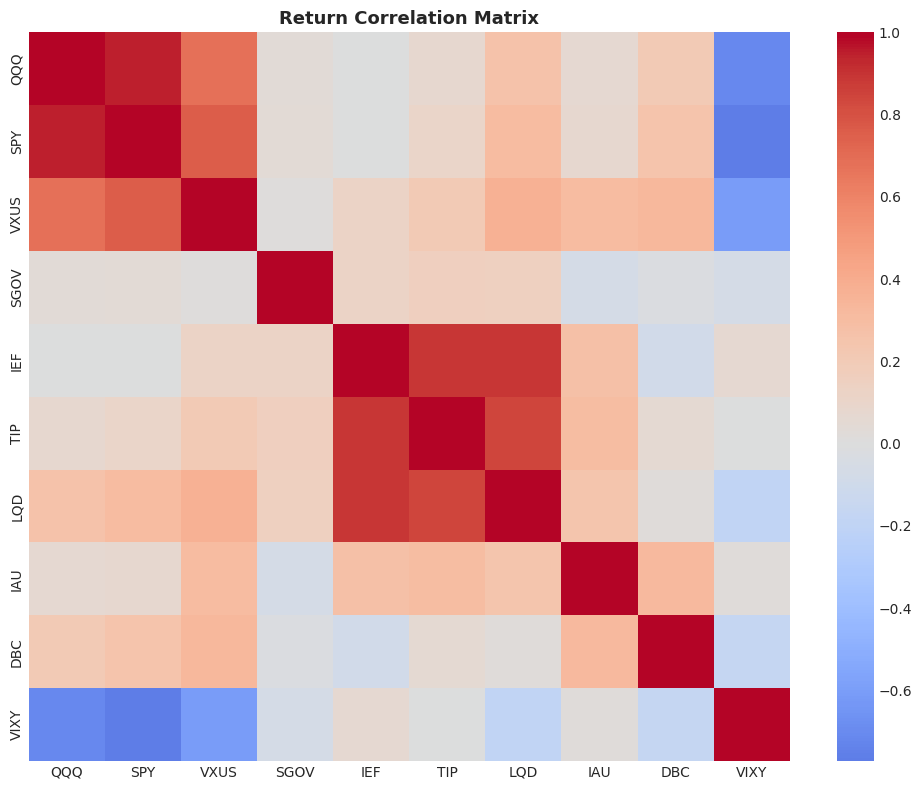

In [82]:
# Cell 8b: Return correlation matrix
returns_df = pd.DataFrame({s: df['return'] for s, df in price_dfs.items()})
correlation = returns_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [83]:
# Cell 8c: Feature engineering for multi-asset regression
from openbb_core.app.utils import df_to_basemodel

feature_frames = {}
for symbol, df in price_dfs.items():
    if df.empty or 'close' not in df.columns:
        continue
    feat = df.copy()
    if 'volume' not in feat.columns:
        feat['volume'] = np.nan

    feat['returns'] = feat['close'].pct_change()
    for lag in [1, 2, 3, 5, 10]:
        feat[f'returns_lag{lag}'] = feat['returns'].shift(lag)

    feat['volatility_20d'] = feat['returns'].rolling(20).std()
    feat['momentum_10d'] = feat['close'].pct_change(10)
    if feat['volume'].notna().any():
        feat['volume_ratio'] = feat['volume'] / feat['volume'].rolling(20).mean()
    else:
        feat['volume_ratio'] = np.nan

    feat = feat.dropna()
    if feat.empty:
        continue

    feat = feat.reset_index()
    feat['symbol'] = symbol
    feature_frames[symbol] = feat

features_df = pd.concat(feature_frames.values(), axis=0) if feature_frames else pd.DataFrame()
print(f"Feature rows: {len(features_df)} across {len(feature_frames)} assets")
features_df.head()


Feature rows: 7320 across 10 assets


,date,open,high,low,close,volume,dividend,return,log_return,cumulative_return,...,returns,returns_lag1,returns_lag2,returns_lag3,returns_lag5,returns_lag10,momentum_10d,volume_ratio,symbol,split_ratio
0,2023-02-07,303.459991,311.029999,302.320007,309.880005,67584000,0.0,0.020719,0.020507,0.145413,...,0.020719,-0.008459,-0.017772,0.035890,0.014986,-0.002042,0.074592,1.273486,QQQ,NaN
1,2023-02-08,308.540009,309.500000,303.670013,304.369995,56720900,0.0,-0.017781,-0.017941,0.125046,...,-0.017781,0.020719,-0.008459,-0.017772,0.021384,-0.002219,0.057832,1.047598,QQQ,NaN
2,2023-02-09,308.839996,308.989990,300.200012,301.679993,49137800,0.0,-0.008838,-0.008877,0.115103,...,-0.008838,-0.017781,0.020719,-0.008459,0.035890,0.019497,0.028431,0.903322,QQQ,NaN
3,2023-02-10,299.480011,301.570007,297.250000,299.700012,50050100,0.0,-0.006563,-0.006585,0.107784,...,-0.006563,-0.008838,-0.017781,0.020719,-0.017772,0.009954,0.011611,0.929103,QQQ,NaN
4,2023-02-13,301.130005,305.100006,299.929993,304.500000,39636700,0.0,0.016016,0.015889,0.125527,...,0.016016,-0.006563,-0.008838,-0.017781,-0.008459,-0.020219,0.049023,0.739339,QQQ,NaN


Geometry embedding summary:
            lambda_1  lambda_2  lambda_3  lambda_4
2026-01-05    3.6907    3.0840    1.1528    0.7368
2026-01-06    3.6743    3.0809    1.1333    0.7494
2026-01-07    3.7057    2.8745    1.1813    0.7764
            rotor_shock  shape_change  regime_index
date                                               
2026-01-05       4.3108        0.0478        2.6056
2026-01-06       4.4320        0.0245        2.6690
2026-01-07       4.4475        0.0886        2.7040


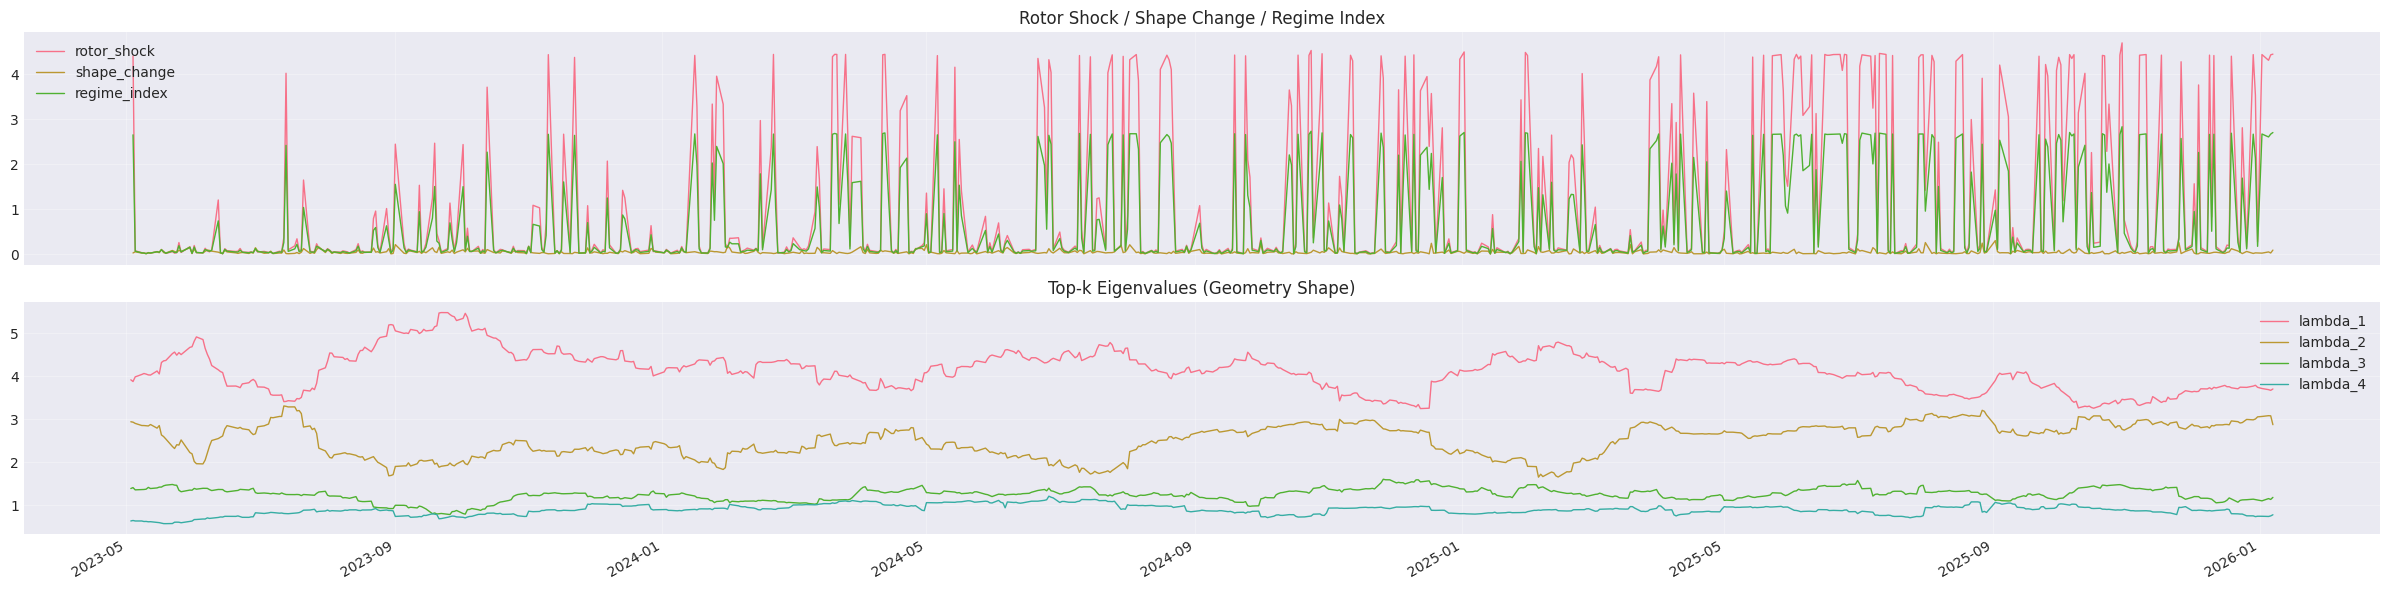

In [84]:
# Cell 8d: Geometry embedding + rotor dynamics (multi-asset)
regression_summaries = []
regression_results = {}
regression_summary_df = None

# Geometry embedding configuration (tune first)
geom_window = 60
geom_k = 4
alpha = 0.6
embedding_mode = 'volume_weighted'  # options: 'plain', 'volume_weighted', 'augmented'
gamma = 0.5  # volume scale for augmented mode
embedding_source = 'geometry'  # options: 'geometry', 'pga'
regime_mix_weight = 0.6  # stress mix: embedding vs rotor regime

assets = [s for s, df in price_dfs.items() if 'close' in df.columns]
embedding_df_geo = pd.DataFrame()
rotor_metrics_df = pd.DataFrame()
geometry_state = None

if len(assets) < 2:
    print('⚠️ Not enough assets for geometry embedding.')
else:
    log_returns_df = pd.DataFrame({s: price_dfs[s]['log_return'] for s in assets})
    volume_df = pd.DataFrame({
        s: price_dfs[s]['volume'] if 'volume' in price_dfs[s].columns else np.nan
        for s in assets
    })

    log_returns_df = log_returns_df.dropna(how='any')
    if log_returns_df.empty:
        print('⚠️ No overlapping return data; skipping geometry embedding.')
    else:
        volume_df = volume_df.reindex(log_returns_df.index)

        vol_est = log_returns_df.ewm(span=20, min_periods=20, adjust=False).std()
        scaled_returns = log_returns_df / vol_est
        scaled_returns = scaled_returns.dropna(how='any')
        volume_df = volume_df.reindex(scaled_returns.index)

        volume_signal = np.log1p(volume_df).diff()
        volume_signal = volume_signal.replace([np.inf, -np.inf], np.nan)
        volume_signal = volume_signal.reindex(scaled_returns.index)
        has_volume = volume_df.notna().any().any()
        if embedding_mode == 'augmented' and not has_volume:
            print('⚠️ No volume data; falling back to plain embedding.')
            embedding_mode = 'plain'

        n_assets = scaled_returns.shape[1]
        embed_dim = n_assets if embedding_mode != 'augmented' else 2 * n_assets
        k = max(1, min(geom_k, embed_dim))

        if len(scaled_returns) < geom_window + 1:
            print('⚠️ Not enough rows for rolling geometry window.')
        else:
            U_list = []
            Lambda_list = []
            C_list = []
            geom_dates = []

            for i in range(geom_window - 1, len(scaled_returns)):
                window_returns = scaled_returns.iloc[i - geom_window + 1:i + 1]
                mu = window_returns.mean()
                sigma = window_returns.std(ddof=0).replace(0, np.nan)
                X = (window_returns - mu) / sigma
                X = X.fillna(0.0).to_numpy()

                if embedding_mode == 'augmented' and has_volume:
                    window_vol = volume_signal.iloc[i - geom_window + 1:i + 1]
                    vol_mu = window_vol.mean()
                    vol_sigma = window_vol.std(ddof=0).replace(0, np.nan)
                    Uv = ((window_vol - vol_mu) / vol_sigma).fillna(0.0).to_numpy()
                    Z = np.hstack([X, gamma * Uv])
                    C = (Z.T @ Z) / len(Z)
                else:
                    if embedding_mode == 'volume_weighted' and has_volume:
                        vol_window = volume_df.iloc[i - geom_window + 1:i + 1]
                        weights = np.log1p(vol_window).mean(axis=1, skipna=True)
                        weights = weights.fillna(weights.mean())
                        if not np.isfinite(weights).any() or weights.sum() == 0:
                            weights = np.ones(len(weights)) / len(weights)
                        else:
                            weights = weights / weights.sum()
                        weight_array = weights.to_numpy() if hasattr(weights, 'to_numpy') else np.asarray(weights)
                        C = (X.T * weight_array).dot(X)
                    else:
                        C = (X.T @ X) / len(X)

                eigvals, eigvecs = np.linalg.eigh(C)
                order = np.argsort(eigvals)[::-1]
                eigvals = eigvals[order]
                eigvecs = eigvecs[:, order]

                U_list.append(eigvecs[:, :k])
                Lambda_list.append(eigvals[:k])
                C_list.append(C)
                geom_dates.append(scaled_returns.index[i])

            try:
                from scipy.linalg import logm
                has_logm = True
            except Exception:
                has_logm = False

            rotor_rows = []
            rotation_k = []
            omega_k = []
            eps = 1e-12

            for j in range(len(U_list) - 1):
                U_t = U_list[j]
                U_next = U_list[j + 1]
                M = U_next.T @ U_t
                A, _, B = np.linalg.svd(M)
                R_k = A @ B
                if np.linalg.det(R_k) < 0:
                    A[:, -1] *= -1
                    R_k = A @ B

                if has_logm:
                    Omega = logm(R_k)
                    Omega = np.real(Omega)
                    Omega = 0.5 * (Omega - Omega.T)
                else:
                    Omega = 0.5 * (R_k - R_k.T)

                shock = float(np.linalg.norm(Omega, ord='fro'))
                lam_t = np.maximum(Lambda_list[j], eps)
                lam_next = np.maximum(Lambda_list[j + 1], eps)
                shape = float(np.linalg.norm(np.log(lam_next) - np.log(lam_t)))
                regime = alpha * shock + (1 - alpha) * shape

                rotation_k.append(R_k)
                omega_k.append(Omega)
                rotor_rows.append({
                    'date': geom_dates[j + 1],
                    'rotor_shock': shock,
                    'shape_change': shape,
                    'regime_index': regime,
                })

            rotor_metrics_df = pd.DataFrame(rotor_rows).set_index('date') if rotor_rows else pd.DataFrame()
            lambda_df = pd.DataFrame(
                Lambda_list,
                index=geom_dates,
                columns=[f'lambda_{i + 1}' for i in range(k)]
            )

            embed_rows = []
            projection_note = 'returns_block' if embedding_mode == 'augmented' else 'direct'
            for date, U, lam in zip(geom_dates, U_list, Lambda_list):
                scale = np.sqrt(np.clip(lam, 0.0, None))
                if embedding_mode == 'augmented':
                    U_assets = U[:n_assets, :k]
                    embed = U_assets * scale
                else:
                    embed = U * scale
                for idx_asset, symbol in enumerate(assets):
                    row = {'date': date, 'symbol': symbol, 'embedding_projection': projection_note}
                    for d in range(embed.shape[1]):
                        row[f'embedding_{d + 1}'] = embed[idx_asset, d]
                    embed_rows.append(row)
            embedding_df_geo = pd.DataFrame(embed_rows)
            if not embedding_df_geo.empty:
                embedding_df_geo['date'] = pd.to_datetime(embedding_df_geo['date'], errors='coerce')
                embedding_df_geo = embedding_df_geo.set_index('date')
                embedding_df_geo = normalize_index(embedding_df_geo)
            if embedding_mode == 'augmented':
                print('ℹ️ Augmented embedding projected onto returns block for per-asset coordinates.')

            geometry_state = {
                'dates': geom_dates,
                'assets': assets,
                'U': U_list,
                'Lambda': Lambda_list,
                'C': C_list,
                'lambda_df': lambda_df,
                'rotor_metrics_df': rotor_metrics_df,
                'rotation_k': rotation_k,
                'omega_k': omega_k,
                'embedding_df': embedding_df_geo,
                'embedding_mode': embedding_mode,
                'window': geom_window,
                'k': k,
            }

            print('Geometry embedding summary:')
            print(lambda_df.tail(3).round(4))
            if not rotor_metrics_df.empty:
                print(rotor_metrics_df.tail(3).round(4))

            import matplotlib.dates as mdates

            fig, ax = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
            if not rotor_metrics_df.empty:
                rotor_metrics_df[['rotor_shock', 'shape_change', 'regime_index']].plot(ax=ax[0], linewidth=1)
                ax[0].set_title('Rotor Shock / Shape Change / Regime Index')
                ax[0].grid(True, alpha=0.3)
            lambda_df.plot(ax=ax[1], linewidth=1)
            ax[1].set_title('Top-k Eigenvalues (Geometry Shape)')
            ax[1].grid(True, alpha=0.3)

            locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
            for axis in ax:
                axis.xaxis.set_major_locator(locator)
                axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            fig.autofmt_xdate()
            plt.tight_layout()
            plt.show()


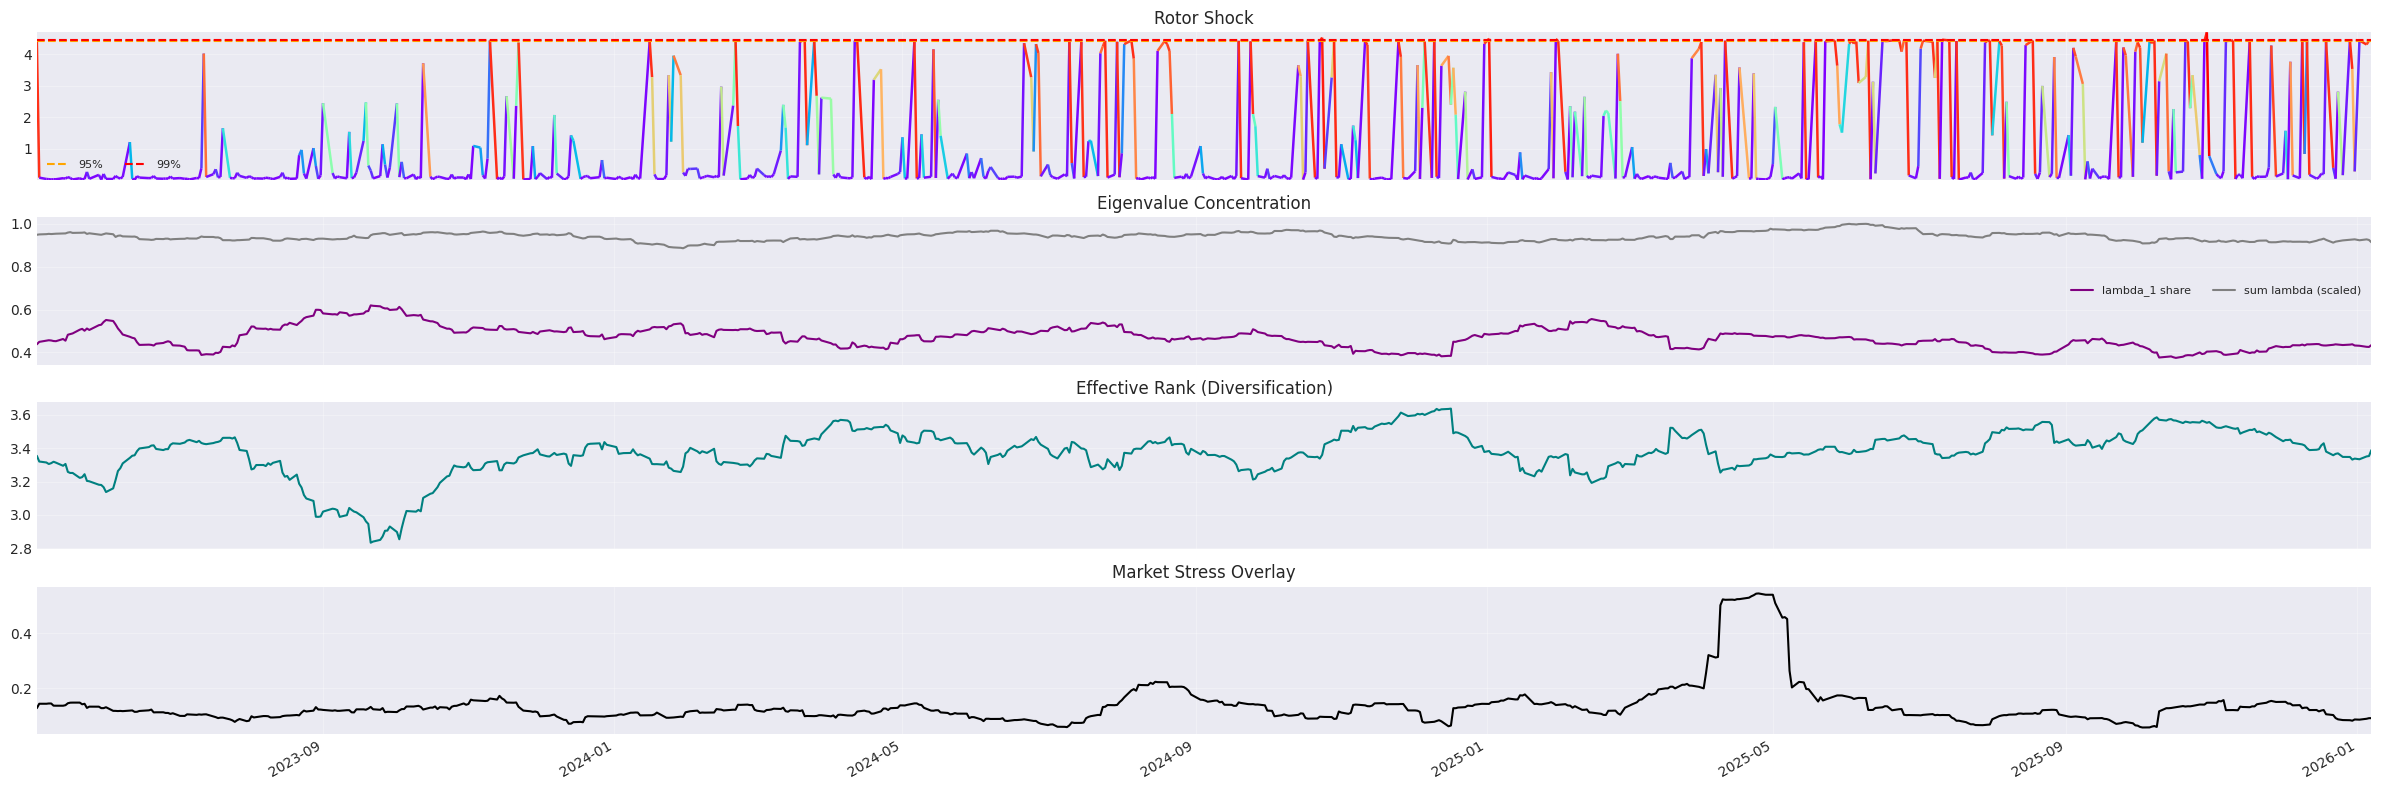

In [85]:
# Cell 8e: Regime dashboard (rotor shock + concentration + effective rank)
if 'geometry_state' not in locals() or not geometry_state:
    print('Warning: geometry_state missing; run Cell 8d.')
else:
    rotor_df = geometry_state.get('rotor_metrics_df', pd.DataFrame()).copy()
    lambda_df = geometry_state.get('lambda_df', pd.DataFrame()).copy()

    if rotor_df.empty or lambda_df.empty:
        print('Warning: rotor_metrics_df or lambda_df empty; skipping dashboard.')
    else:
        import matplotlib.dates as mdates
        from matplotlib.collections import LineCollection

        lambda_aligned = lambda_df.reindex(rotor_df.index).ffill().bfill()
        total_lambda = lambda_aligned.sum(axis=1).replace(0, np.nan)
        top1_share = (lambda_aligned.iloc[:, 0] / total_lambda).rename('top1_share')
        p = lambda_aligned.div(total_lambda, axis=0)
        effrank = np.exp(-(p * np.log(p + 1e-12)).sum(axis=1)).rename('eff_rank')
        shock = rotor_df['rotor_shock'].dropna().rename('rotor_shock')

        q95 = shock.quantile(0.95)
        q99 = shock.quantile(0.99)

        stress_panel = pd.Series(dtype=float)
        if 'SPY' in price_dfs:
            spy_ret = price_dfs['SPY']['close'].pct_change()
            stress_panel = spy_ret.rolling(20).std() * np.sqrt(252)
            stress_panel = stress_panel.reindex(rotor_df.index)
        elif price_dfs:
            sym0 = next(iter(price_dfs))
            ret0 = price_dfs[sym0]['close'].pct_change()
            stress_panel = ret0.rolling(20).std() * np.sqrt(252)
            stress_panel = stress_panel.reindex(rotor_df.index)

        n_panels = 4 if not stress_panel.empty else 3
        fig, axes = plt.subplots(n_panels, 1, figsize=(24, 8), sharex=True)

        x_num = mdates.date2num(shock.index.to_pydatetime())
        y_vals = shock.values
        if len(y_vals) > 1:
            points = np.array([x_num, y_vals]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap='rainbow', norm=plt.Normalize(np.nanmin(y_vals), np.nanmax(y_vals)))
            lc.set_array(y_vals)
            lc.set_linewidth(1.8)
            axes[0].add_collection(lc)
            axes[0].set_xlim(x_num.min(), x_num.max())
            axes[0].set_ylim(np.nanmin(y_vals), np.nanmax(y_vals))
        else:
            axes[0].plot(shock.index, shock.values, label='rotor_shock', color='steelblue', linewidth=1.8)

        axes[0].axhline(q95, color='orange', linestyle='--', label='95%')
        axes[0].axhline(q99, color='red', linestyle='--', label='99%')
        axes[0].set_title('Rotor Shock')
        axes[0].legend(ncol=3, fontsize=8)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(top1_share.index, top1_share.values, label='lambda_1 share', color='purple')
        lambda_sum_scaled = total_lambda / total_lambda.max()
        axes[1].plot(lambda_sum_scaled.index, lambda_sum_scaled.values, label='sum lambda (scaled)', color='gray')
        axes[1].set_title('Eigenvalue Concentration')
        axes[1].legend(ncol=2, fontsize=8)
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(effrank.index, effrank.values, label='effective_rank', color='teal')
        axes[2].set_title('Effective Rank (Diversification)')
        axes[2].grid(True, alpha=0.3)

        if n_panels == 4:
            axes[3].plot(stress_panel.index, stress_panel.values, label='realized_vol_20d', color='black')
            axes[3].set_title('Market Stress Overlay')
            axes[3].grid(True, alpha=0.3)

        locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
        for axis in axes:
            axis.xaxis.set_major_locator(locator)
            axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()

        plt.tight_layout()
        plt.show()


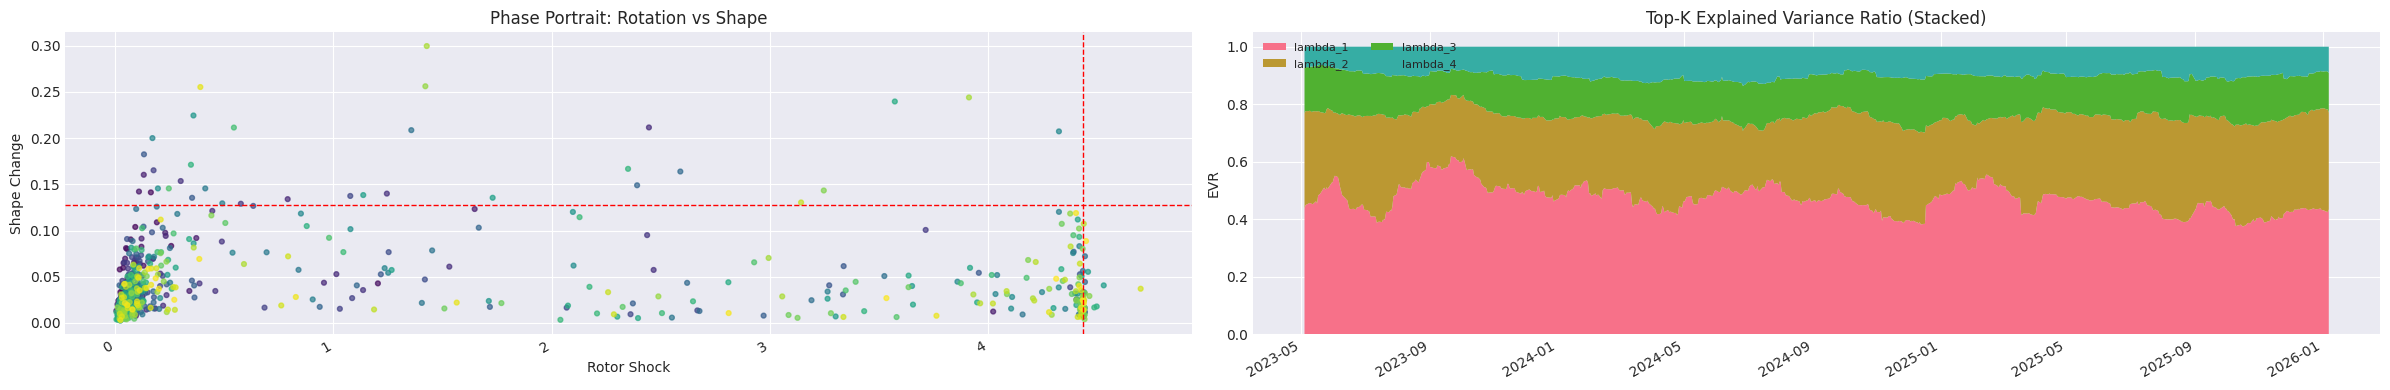

In [86]:
# Cell 8f: Phase portrait + explained variance area
if 'geometry_state' not in locals() or not geometry_state:
    print('Warning: geometry_state missing; run Cell 8d.')
else:
    rotor_df = geometry_state.get('rotor_metrics_df', pd.DataFrame()).copy()
    lambda_df = geometry_state.get('lambda_df', pd.DataFrame()).copy()

    if rotor_df.empty or lambda_df.empty:
        print('Warning: rotor_metrics_df or lambda_df empty; skipping phase portrait.')
    else:
        import matplotlib.dates as mdates

        lambda_aligned = lambda_df.reindex(rotor_df.index).ffill().bfill()
        total_lambda = lambda_aligned.sum(axis=1).replace(0, np.nan)
        evr = lambda_aligned.div(total_lambda, axis=0).fillna(0.0)

        x = rotor_df['rotor_shock']
        y = rotor_df['shape_change']
        qx = x.quantile(0.95)
        qy = y.quantile(0.95)

        mask = x.notna() & y.notna()
        fig, axes = plt.subplots(1, 2, figsize=(24, 4))
        axes[0].scatter(x[mask], y[mask], c=np.arange(mask.sum()), cmap='viridis', s=12, alpha=0.7)
        axes[0].axvline(qx, color='red', linestyle='--', linewidth=1)
        axes[0].axhline(qy, color='red', linestyle='--', linewidth=1)
        axes[0].set_xlabel('Rotor Shock')
        axes[0].set_ylabel('Shape Change')
        axes[0].set_title('Phase Portrait: Rotation vs Shape')

        axes[1].stackplot(evr.index, evr.T, labels=evr.columns)
        axes[1].set_title('Top-K Explained Variance Ratio (Stacked)')
        axes[1].set_ylabel('EVR')
        axes[1].legend(ncol=2, fontsize=8, loc='upper left')

        locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
        axes[1].xaxis.set_major_locator(locator)
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()

        plt.tight_layout()
        plt.show()


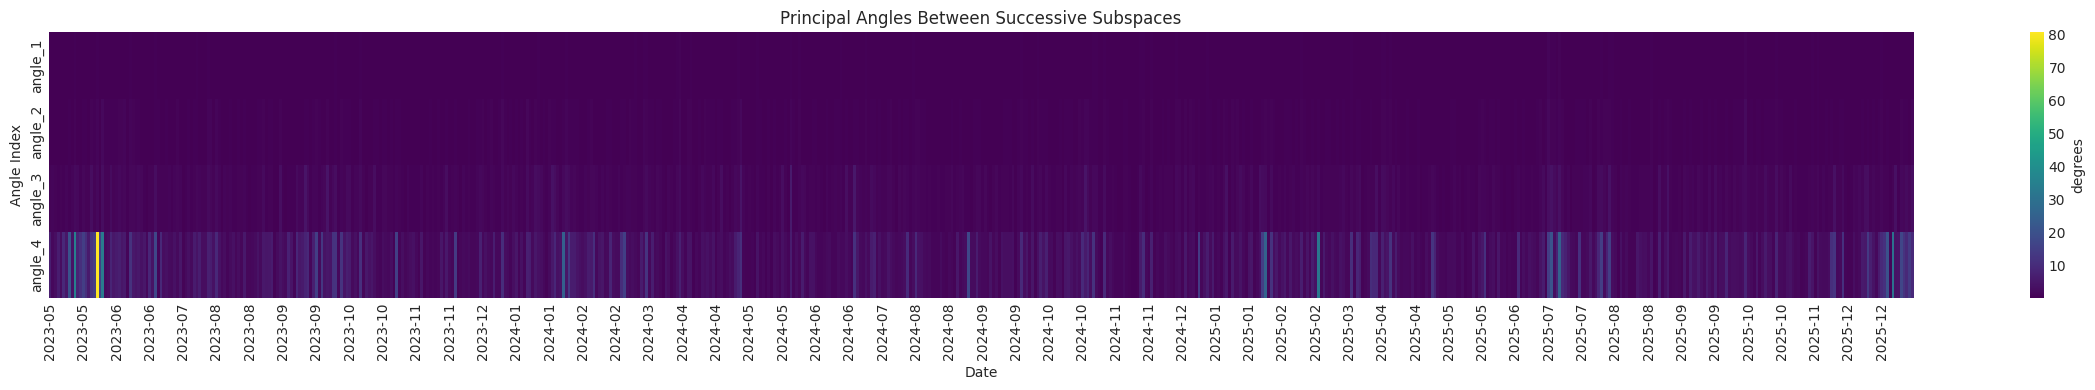

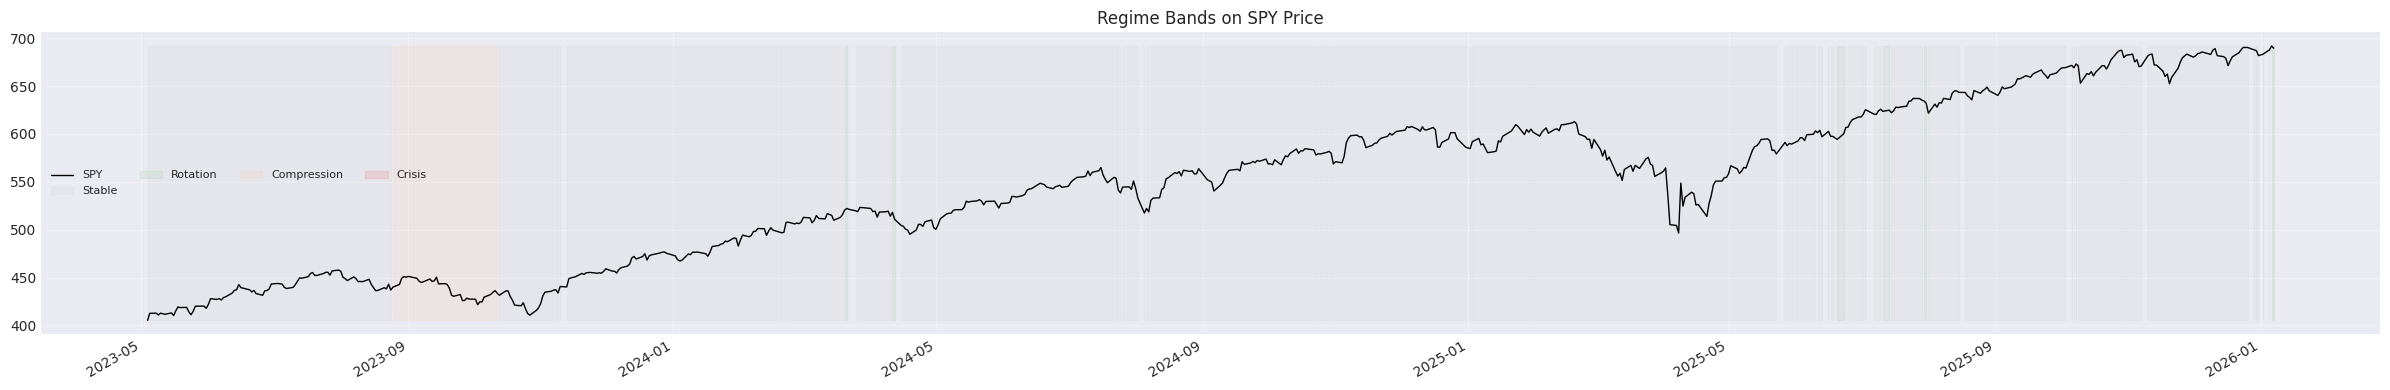

In [87]:
# Cell 8g: Principal angle heatmap + regime bands
if 'geometry_state' not in locals() or not geometry_state:
    print('Warning: geometry_state missing; run Cell 8d.')
else:
    rotor_df = geometry_state.get('rotor_metrics_df', pd.DataFrame()).copy()
    lambda_df = geometry_state.get('lambda_df', pd.DataFrame()).copy()
    U_list = geometry_state.get('U', [])

    if rotor_df.empty or lambda_df.empty or len(U_list) < 2:
        print('Warning: missing geometry snapshots; skipping angle heatmap.')
    else:
        angle_rows = []
        for j in range(len(U_list) - 1):
            U_t = U_list[j]
            U_next = U_list[j + 1]
            svals = np.linalg.svd(U_next.T @ U_t, compute_uv=False)
            svals = np.clip(svals, -1.0, 1.0)
            angles = np.arccos(svals)
            angle_rows.append(angles)

        angles_arr = np.array(angle_rows)
        angle_df = pd.DataFrame(
            angles_arr,
            index=rotor_df.index,
            columns=[f'angle_{i + 1}' for i in range(angles_arr.shape[1])]
        )

        angle_plot = angle_df.T.copy()
        if isinstance(angle_plot.columns, pd.DatetimeIndex):
            angle_plot.columns = angle_plot.columns.strftime('%Y-%m')

        with sns.axes_style('white'):
            fig, ax = plt.subplots(figsize=(24, 4))
            sns.heatmap(
                angle_plot * 180 / np.pi,
                cmap='viridis',
                cbar_kws={'label': 'degrees'},
                ax=ax,
                xticklabels=12
            )
            ax.set_title('Principal Angles Between Successive Subspaces')
            ax.set_xlabel('Date')
            ax.set_ylabel('Angle Index')
            ax.set_facecolor('white')
            fig.patch.set_facecolor('white')
            plt.tight_layout()
            plt.show()

    if rotor_df.empty or lambda_df.empty:
        print('Warning: missing rotor/lambda data; skipping regime bands.')
    else:
        import matplotlib.dates as mdates

        lambda_aligned = lambda_df.reindex(rotor_df.index).ffill().bfill()
        total_lambda = lambda_aligned.sum(axis=1).replace(0, np.nan)
        top1_share = (lambda_aligned.iloc[:, 0] / total_lambda).rename('top1_share')

        shock = rotor_df['rotor_shock']
        shock_q = shock.quantile(0.95)
        conc_q = top1_share.quantile(0.95)

        rotation_mask = shock > shock_q
        compression_mask = top1_share > conc_q
        labels = pd.Series('Stable', index=rotor_df.index)
        labels[rotation_mask & ~compression_mask] = 'Rotation'
        labels[compression_mask & ~rotation_mask] = 'Compression'
        labels[rotation_mask & compression_mask] = 'Crisis'

        price_symbol = 'SPY' if 'SPY' in price_dfs else (next(iter(price_dfs), None))
        if price_symbol is None:
            print('Warning: no price series for regime bands.')
        else:
            price = price_dfs[price_symbol]['close'].reindex(rotor_df.index).ffill().bfill()
            ymin, ymax = price.min(), price.max()

            colors = {
                'Stable': '#c7c7c7',
                'Rotation': '#7fc97f',
                'Compression': '#fdc086',
                'Crisis': '#ef3b2c',
            }

            fig, ax = plt.subplots(figsize=(24, 4))
            ax.plot(price.index, price.values, color='black', linewidth=1, label=price_symbol)
            for label, color in colors.items():
                mask = labels == label
                ax.fill_between(price.index, ymin, ymax, where=mask, color=color, alpha=0.12, label=label)
            ax.set_title(f'Regime Bands on {price_symbol} Price')
            ax.legend(ncol=4, fontsize=8)
            ax.grid(True, alpha=0.3)

            locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            fig.autofmt_xdate()

            plt.tight_layout()
            plt.show()


### Workflow Templates (Multi-Asset)

**Use Case 1: ML-Driven Strategy Research**
```python
# Pipeline -> Regression -> Save -> Export
%openbb_pipeline steps=technical.sma:length=50,technical.rsi:length=14 data=prices save_final=true name=multi_asset_pipeline
regression_result = obb.analytics.stats.regression(data=feature_list, y='returns', x=['returns_lag1', 'volatility_20d'])
store.save(regression_result, name='multi_asset_regression', tags=['research'])
%openbb_export_to_cli result_id=<result_id> output=./multi_asset_pipeline.sh
```

**Use Case 2: Multi-Strategy Comparison**
```python
compare = obb.analytics.compare.strategies(
    result_ids=[<id_1>, <id_2>],
    metrics=['r_squared', 'adj_r_squared'],
    normalize=True
)
```

**Use Case 3: Production Workflow Template**
```python
# 1) Build signals  2) Train model  3) Save artifacts  4) Export CLI runner
signals = obb.technical.sma(data=prices, length=50)
model = obb.analytics.stats.regression(data=feature_list, y='returns', x=['returns_lag1'])
store.save(model, name='multi_asset_model_prod', tags=['production'])
%openbb_export_to_cli result_id=<result_id> output=./deploy_model.sh
```


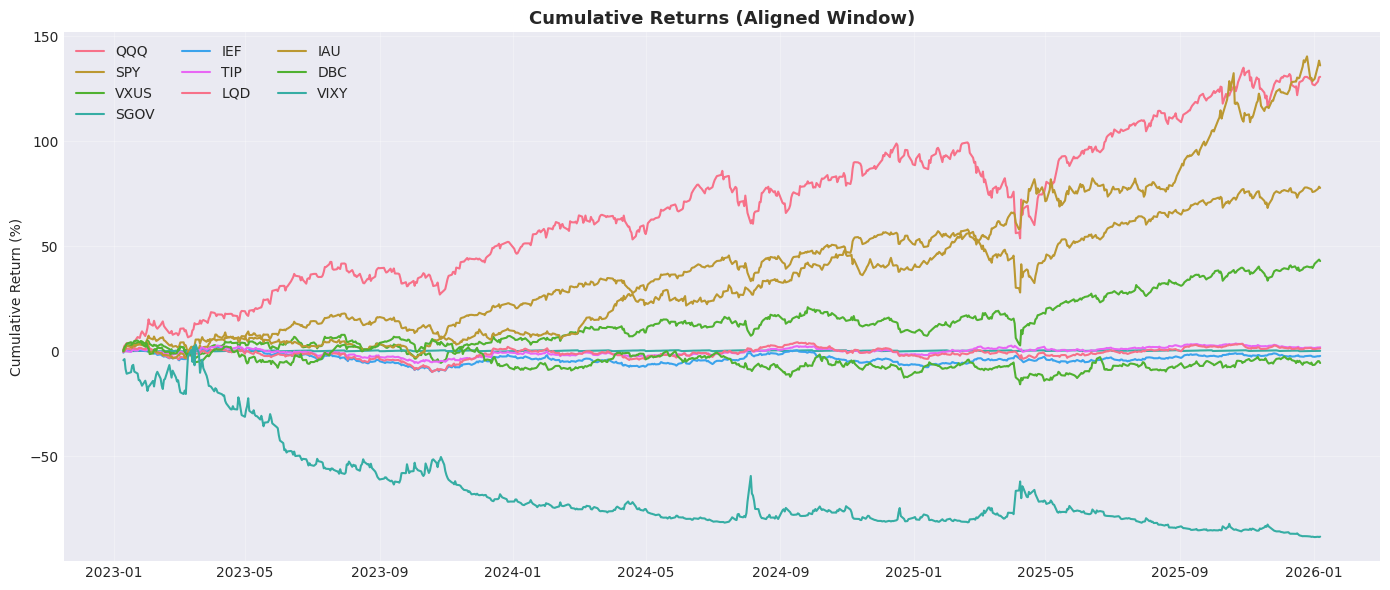

In [88]:
# Cell 9: Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))
for symbol, df in price_dfs.items():
    ax.plot(df.index, df['cumulative_return'] * 100, label=symbol)
ax.set_title('Cumulative Returns (Aligned Window)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


In [93]:
# Cell 10: Run multi-asset embedding (geometry preferred) + diagnostics
embedding_df_geo = embedding_df_geo if 'embedding_df_geo' in locals() else pd.DataFrame()
embedding_df_pga = pd.DataFrame()
embedding_source = embedding_source if 'embedding_source' in locals() else 'pga'
geometry_metrics_df = pd.DataFrame()

# Always build base data map for downstream clustering/distance
pga_data = {}
for symbol, df in price_dfs.items():
    if df.empty:
        continue
    df = df.copy()
    df.index.name = 'date'
    pga_data[symbol] = df_to_basemodel(df, index=True)

if embedding_source == 'geometry' and not embedding_df_geo.empty:
    embedding_df = embedding_df_geo.copy()
    print('✅ Using geometry embedding from rolling correlation state')
else:
    if embedding_source == 'geometry':
        print('⚠️ Geometry embedding unavailable; falling back to PGA.')

    pga_result = obb.analytics.geometry.pga_multi_asset(
        data=pga_data,
        window=20,
        fields=['close'],
        basis_method='pca',
        target_geometry='euclidean'
    )

    embedding_df_pga = basemodel_to_df(pga_result.results)
    embedding_df_pga = normalize_index(embedding_df_pga)
    embedding_df = embedding_df_pga
    print('✅ Using PGA embedding')

embedding_df = normalize_index(embedding_df)
check_df('embedding_df', embedding_df, required_cols=['symbol'])

# Geometry diagnostics from 8d
if 'geometry_state' in locals() and geometry_state:
    rotor_df = geometry_state.get('rotor_metrics_df', pd.DataFrame()).copy()
    lambda_df = geometry_state.get('lambda_df', pd.DataFrame()).copy()
    if not rotor_df.empty and not lambda_df.empty:
        lambda_aligned = lambda_df.reindex(rotor_df.index).ffill().bfill()
        total_lambda = lambda_aligned.sum(axis=1).replace(0, np.nan)
        top1_share = (lambda_aligned.iloc[:, 0] / total_lambda)
        p = lambda_aligned.div(total_lambda, axis=0)
        effrank = np.exp(-(p * np.log(p + 1e-12)).sum(axis=1))

        geometry_metrics_df = pd.DataFrame({
            'rotor_shock': rotor_df['rotor_shock'],
            'shape_change': rotor_df['shape_change'],
            'regime_index': rotor_df['regime_index'],
            'top1_share': top1_share,
            'eff_rank': effrank,
        })
        geometry_metrics_df = geometry_metrics_df.sort_index()

        latest_idx = geometry_metrics_df.index.max()
        latest_metrics = geometry_metrics_df.loc[latest_idx]
        print('Geometry diagnostics (latest):')
        print(latest_metrics.round(4))

print(embedding_df.head())


✅ Using geometry embedding from rolling correlation state
🔎 embedding_df: shape=(673, 6)
   index: datetime (2023-05-03 00:00:00 -> 2026-01-07 00:00:00)
Geometry diagnostics (latest):
rotor_shock     4.4475
shape_change    0.0886
regime_index    2.7040
top1_share      0.4340
eff_rank        3.3887
Name: 2026-01-07 00:00:00, dtype: float64
           symbol embedding_projection  embedding_1  embedding_2  embedding_3  \
date                                                                            
2023-05-03   VIXY               direct     0.867418     0.307217    -0.104978   
2023-05-04   VIXY               direct     0.855162     0.326013     0.107201   
2023-05-05   VIXY               direct     0.862180     0.314032     0.103602   
2023-05-08   VIXY               direct     0.867734     0.306576     0.107135   
2023-05-09   VIXY               direct     0.872987     0.296675     0.104528   

            embedding_4  
date                     
2023-05-03     0.046215  
2023-05-04   

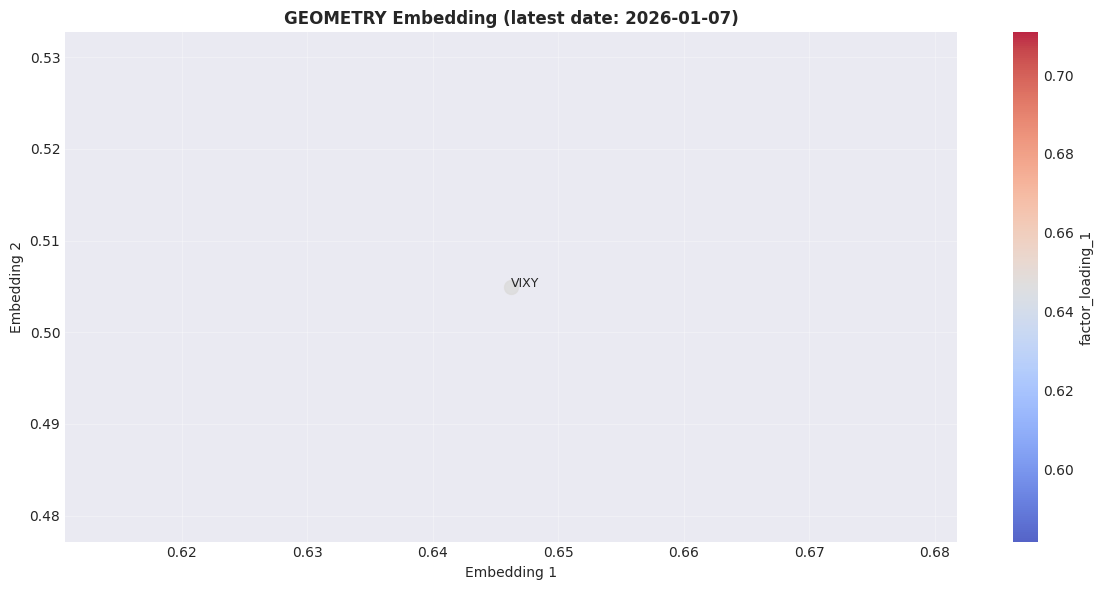

In [94]:
# Cell 10a: Embedding scatter (latest date)
import numpy as np

if embedding_df.empty:
    print('⚠️ embedding_df is empty; skipping scatter.')
else:
    latest_date = embedding_df.index.max()
    latest = embedding_df.loc[latest_date]
    if isinstance(latest, pd.Series):
        latest = latest.to_frame().T

    if not {'embedding_1', 'embedding_2'}.issubset(latest.columns):
        print('⚠️ embedding_1/embedding_2 missing; skipping scatter.')
    else:
        latest = latest.copy()
        # Ensure the columns are cast to float to handle potential object-dtype issues
        # from mixed-type DataFrames or Series.
        latest['embed_norm'] = np.sqrt((latest[['embedding_1', 'embedding_2']].astype(float).values ** 2).sum(axis=1))

        color_vals = None
        color_label = 'embed_norm'
        if 'geometry_state' in locals() and geometry_state:
            U_list = geometry_state.get('U', [])
            Lambda_list = geometry_state.get('Lambda', [])
            assets = geometry_state.get('assets', []) if isinstance(geometry_state, dict) else []
            if U_list and Lambda_list and assets:
                U_last = U_list[-1]
                lam_last = Lambda_list[-1]
                n_assets = len(assets)
                if U_last.shape[0] >= n_assets:
                    loadings = U_last[:n_assets, 0] * np.sqrt(max(lam_last[0], 0))
                    loading_df = pd.DataFrame({'symbol': assets, 'factor_loading': loadings})
                    latest = latest.merge(loading_df, on='symbol', how='left')
                    if latest['factor_loading'].notna().any():
                        color_vals = latest['factor_loading']
                        color_label = 'factor_loading_1'

        fig, ax = plt.subplots(figsize=(12, 6))
        if color_vals is None:
            color_vals = latest['embed_norm']
        sc = ax.scatter(
            latest['embedding_1'],
            latest['embedding_2'],
            c=color_vals,
            s=40 + 60 * (latest['embed_norm'] / latest['embed_norm'].max()),
            cmap='coolwarm',
            alpha=0.85
        )
        for _, row in latest.iterrows():
            ax.annotate(row.get('symbol', 'multi_asset'), (row['embedding_1'], row['embedding_2']), fontsize=9)
        source_label = embedding_source.upper() if 'embedding_source' in locals() else 'PGA'
        ax.set_title(f'{source_label} Embedding (latest date: {latest_date.date()})', fontsize=12, fontweight='bold')
        ax.set_xlabel('Embedding 1')
        ax.set_ylabel('Embedding 2')
        ax.grid(True, alpha=0.3)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(color_label)
        plt.tight_layout()
        plt.show()


In [96]:
# Cell 10b: 3D phase space (optional)
if HAS_PLOTLY and not embedding_df.empty:
    latest_date = embedding_df.index.max()
    latest = embedding_df.loc[latest_date]
    if isinstance(latest, pd.Series):
        latest = latest.to_frame().T

    required_cols = {'embedding_1', 'embedding_2', 'embedding_3'}
    if not required_cols.issubset(latest.columns):
        print('⚠️ embedding_1/embedding_2/embedding_3 missing; skipping 3D plot.')
    else:
        latest = latest.copy()
        #latest['embed_norm'] = np.sqrt((latest[['embedding_1', 'embedding_2', 'embedding_3']].values ** 2).sum(axis=1))
        latest['embed_norm'] = np.sqrt(
            (latest[['embedding_1', 'embedding_2', 'embedding_3']].astype(float).values ** 2).sum(axis=1))
        color_field = 'embed_norm'

        if 'geometry_state' in locals() and geometry_state:
            U_list = geometry_state.get('U', [])
            Lambda_list = geometry_state.get('Lambda', [])
            assets = geometry_state.get('assets', []) if isinstance(geometry_state, dict) else []
            if U_list and Lambda_list and assets:
                U_last = U_list[-1]
                lam_last = Lambda_list[-1]
                n_assets = len(assets)
                if U_last.shape[0] >= n_assets:
                    loadings = U_last[:n_assets, 0] * np.sqrt(max(lam_last[0], 0))
                    loading_df = pd.DataFrame({'symbol': assets, 'factor_loading': loadings})
                    latest = latest.merge(loading_df, on='symbol', how='left')
                    if latest['factor_loading'].notna().any():
                        color_field = 'factor_loading'

        source_label = embedding_source.upper() if 'embedding_source' in locals() else 'PGA'
        fig = px.scatter_3d(
            latest,
            x='embedding_1',
            y='embedding_2',
            z='embedding_3',
            color=color_field,
            size='embed_norm',
            hover_name='symbol',
            title=f'3D {source_label} Phase Space ({latest_date.date()})'
        )
        fig.show()
else:
    print('⚠️ Plotly unavailable or embedding_df empty.')

In [ ]:
# Cell 11: Stress metrics from embeddings
if embedding_df.empty:
    print('⚠️ embedding_df is empty; skipping stress metrics.')
    stress_dim_df = pd.DataFrame()
    stress_index = pd.Series(dtype=float)
    embed_dims = []
    stress_components_df = pd.DataFrame()
else:
    embed_cols = [
        c for c in embedding_df.columns if c.startswith('embedding_')]
    embed_dims = embed_cols[:3] if len(embed_cols) >= 3 else embed_cols
    if not embed_dims:
        print('⚠️ No embedding dimensions found; skipping stress metrics.')
        stress_dim_df = pd.DataFrame()
        stress_index = pd.Series(dtype=float)
        stress_components_df = pd.DataFrame()
    else:
        embedding_df = embedding_df.copy()

        # FIX: Convert embedding columns to numeric types to prevent TypeError.
        # 'errors="coerce"' will turn non-parseable strings into NaN.
        embedding_df[embed_dims] = embedding_df[embed_dims].apply(
            pd.to_numeric, errors='coerce')

        # Now the calculation will work on float values
        embedding_df['stress'] = np.sqrt(
            (embedding_df[embed_dims] ** 2).sum(axis=1))

        stress_wide = embedding_df.pivot_table(
            index=embedding_df.index, columns='symbol', values='stress')
        dim_std = embedding_df.pivot_table(
            index=embedding_df.index, columns='symbol', values=embed_dims)

        stress_dim = {}
        for dim in embed_dims:
            # dim_std has MultiIndex columns (Dimension, Symbol)
            if dim in dim_std:
                dim_df = dim_std[dim]
                stress_dim[dim] = dim_df.std(axis=1)

        stress_dim_df = pd.DataFrame(stress_dim)
        stress_dim_df['stress_index_raw'] = stress_dim_df.max(axis=1)

        geometry_regime = pd.Series(dtype=float)
        concentration_score = pd.Series(dtype=float)
        if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
            geom_metrics = geometry_metrics_df.reindex(
                stress_dim_df.index).ffill().bfill()
            stress_dim_df['rotor_shock'] = geom_metrics.get('rotor_shock')
            stress_dim_df['shape_change'] = geom_metrics.get('shape_change')
            stress_dim_df['top1_share'] = geom_metrics.get('top1_share')
            stress_dim_df['eff_rank'] = geom_metrics.get('eff_rank')
            geometry_regime = geom_metrics.get(
                'regime_index', pd.Series(dtype=float))

            if geom_metrics.get('top1_share') is not None:
                concentration_score = zscore(geom_metrics['top1_share'])
            elif geom_metrics.get('eff_rank') is not None:
                concentration_score = -zscore(geom_metrics['eff_rank'])

        components = {
            'embed': zscore(stress_dim_df['stress_index_raw']),
        }
        if not geometry_regime.empty:
            components['rotor'] = zscore(geometry_regime)
        if not concentration_score.empty:
            components['concentration'] = concentration_score

        weights = {'embed': 0.5, 'rotor': 0.3, 'concentration': 0.2}
        available = {k: v for k, v in components.items() if not v.isna().all()}
        if available:
            total_w = sum(weights.get(k, 0.0) for k in available)
            if total_w == 0:
                total_w = len(available)
            combined = sum(available[k] * weights.get(k, 1.0)
                           for k in available) / total_w
            stress_dim_df['stress_index'] = combined
        else:
            stress_dim_df['stress_index'] = stress_dim_df['stress_index_raw']

        stress_index = stress_dim_df['stress_index']
        stress_components_df = pd.DataFrame(available)

        print('Stress index stats:')
        print(stress_dim_df['stress_index'].describe().round(4))


Stress index stats:
count    673.0000
mean      -0.0000
std        0.6551
min       -1.1309
25%       -0.4606
50%       -0.1330
75%        0.5072
max        1.7065
Name: stress_index, dtype: float64


"\n# Cell 11: Stress metrics from embeddings\nif embedding_df.empty:\n    print('⚠️ embedding_df is empty; skipping stress metrics.')\n    stress_dim_df = pd.DataFrame()\n    stress_index = pd.Series(dtype=float)\n    embed_dims = []\n    stress_components_df = pd.DataFrame()\nelse:\n    embed_cols = [c for c in embedding_df.columns if c.startswith('embedding_')]\n    embed_dims = embed_cols[:3] if len(embed_cols) >= 3 else embed_cols\n    if not embed_dims:\n        print('⚠️ No embedding dimensions found; skipping stress metrics.')\n        stress_dim_df = pd.DataFrame()\n        stress_index = pd.Series(dtype=float)\n        stress_components_df = pd.DataFrame()\n    else:\n        embedding_df = embedding_df.copy()\n        embedding_df['stress'] = np.sqrt((embedding_df[embed_dims] ** 2).sum(axis=1))\n\n        stress_wide = embedding_df.pivot_table(index=embedding_df.index, columns='symbol', values='stress')\n        dim_std = embedding_df.pivot_table(index=embedding_df.index, col

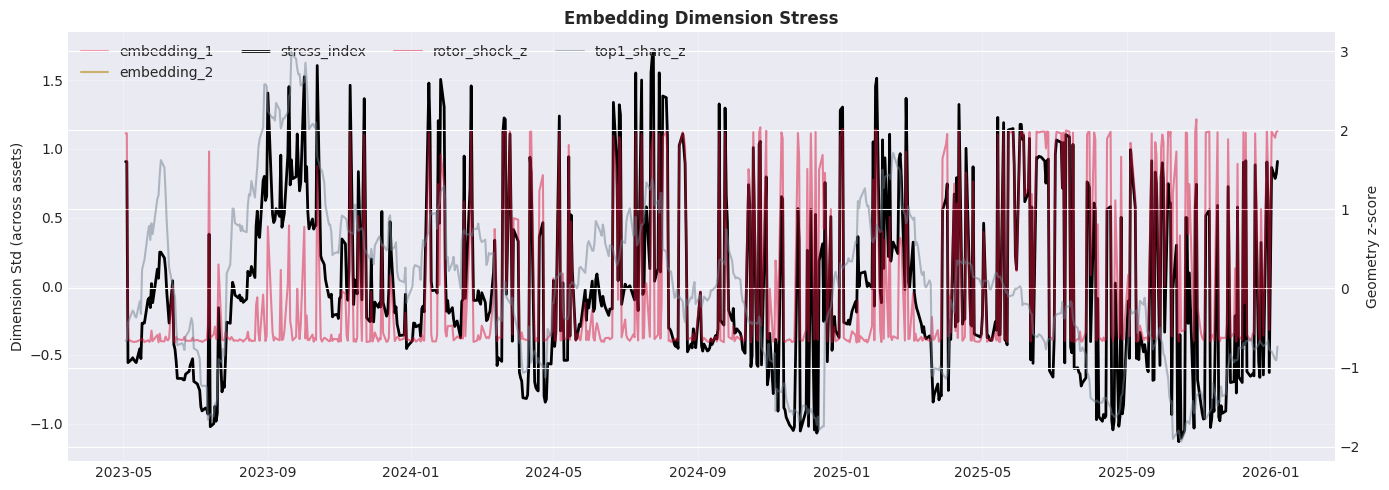

"\n# Cell 11a: Dimension stress over time\nfig, ax = plt.subplots(figsize=(14, 5))\nfor dim in embed_dims if 'embed_dims' in locals() else []:\n    if dim in stress_dim_df.columns:\n        ax.plot(stress_dim_df.index, stress_dim_df[dim], label=dim)\nif 'stress_index' in stress_dim_df.columns:\n    ax.plot(stress_dim_df.index, stress_dim_df['stress_index'], color='black', linewidth=2, label='stress_index')\nax.set_title('Embedding Dimension Stress', fontsize=12, fontweight='bold')\nax.set_ylabel('Dimension Std (across assets)')\n\nif 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:\n    overlay = geometry_metrics_df.reindex(stress_dim_df.index).ffill().bfill()\n    ax2 = ax.twinx()\n    if 'rotor_shock' in overlay:\n        ax2.plot(overlay.index, zscore(overlay['rotor_shock']), color='crimson', alpha=0.5, label='rotor_shock_z')\n    if 'top1_share' in overlay:\n        ax2.plot(overlay.index, zscore(overlay['top1_share']), color='slategray', alpha=0.5, label='top1_

In [98]:
# Cell 11a: Dimension stress over time
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore

# 1. Check if prerequisites exist
if 'stress_dim_df' not in locals() or stress_dim_df.empty:
    print("⚠️ 'stress_dim_df' is missing or empty. Ensure Cell 11 ran successfully.")
else:
    fig, ax = plt.subplots(figsize=(14, 5))

    # 2. Get dimensions to plot
    # Ensure embed_dims exists
    dims_to_plot = embed_dims if 'embed_dims' in locals() else []

    has_data = False

    # Plot embedding dimensions
    for dim in dims_to_plot:
        if dim in stress_dim_df.columns:
            ax.plot(stress_dim_df.index, stress_dim_df[dim], label=dim, alpha=0.7)
            has_data = True

    # Plot stress index
    if 'stress_index' in stress_dim_df.columns:
        ax.plot(stress_dim_df.index, stress_dim_df['stress_index'], color='black', linewidth=2, label='stress_index')
        has_data = True

    if not has_data:
        print("⚠️ 'stress_dim_df' exists but contains no matching columns to plot.")

    ax.set_title('Embedding Dimension Stress', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dimension Std (across assets)')

    # 3. Overlay Geometry Metrics
    if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
        overlay = geometry_metrics_df.reindex(stress_dim_df.index).ffill().bfill()
        ax2 = ax.twinx()

        # Helper to safely plot z-scores
        def plot_zscore(col_name, color, label):
            if col_name in overlay.columns:
                series = overlay[col_name].dropna()
                if not series.empty and series.std() > 0:
                    z_vals = zscore(series)
                    # Align back to overlay index
                    z_series = pd.Series(z_vals, index=series.index).reindex(overlay.index)
                    ax2.plot(overlay.index, z_series, color=color, alpha=0.5, label=label)
                    return True
            return False

        l1 = plot_zscore('rotor_shock', 'crimson', 'rotor_shock_z')
        l2 = plot_zscore('top1_share', 'slategray', 'top1_share_z')

        if l1 or l2:
            ax2.set_ylabel('Geometry z-score')
            lines_1, labels_1 = ax.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            ax.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=4, loc='upper left')
        else:
            ax.legend(ncol=4, loc='upper left')
    else:
        ax.legend(ncol=4, loc='upper left')

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
'''
# Cell 11a: Dimension stress over time
fig, ax = plt.subplots(figsize=(14, 5))
for dim in embed_dims if 'embed_dims' in locals() else []:
    if dim in stress_dim_df.columns:
        ax.plot(stress_dim_df.index, stress_dim_df[dim], label=dim)
if 'stress_index' in stress_dim_df.columns:
    ax.plot(stress_dim_df.index, stress_dim_df['stress_index'], color='black', linewidth=2, label='stress_index')
ax.set_title('Embedding Dimension Stress', fontsize=12, fontweight='bold')
ax.set_ylabel('Dimension Std (across assets)')

if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
    overlay = geometry_metrics_df.reindex(stress_dim_df.index).ffill().bfill()
    ax2 = ax.twinx()
    if 'rotor_shock' in overlay:
        ax2.plot(overlay.index, zscore(overlay['rotor_shock']), color='crimson', alpha=0.5, label='rotor_shock_z')
    if 'top1_share' in overlay:
        ax2.plot(overlay.index, zscore(overlay['top1_share']), color='slategray', alpha=0.5, label='top1_share_z')
    ax2.set_ylabel('Geometry z-score')

    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=4)
else:
    ax.legend(ncol=4)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
'''

Early warning count: 31


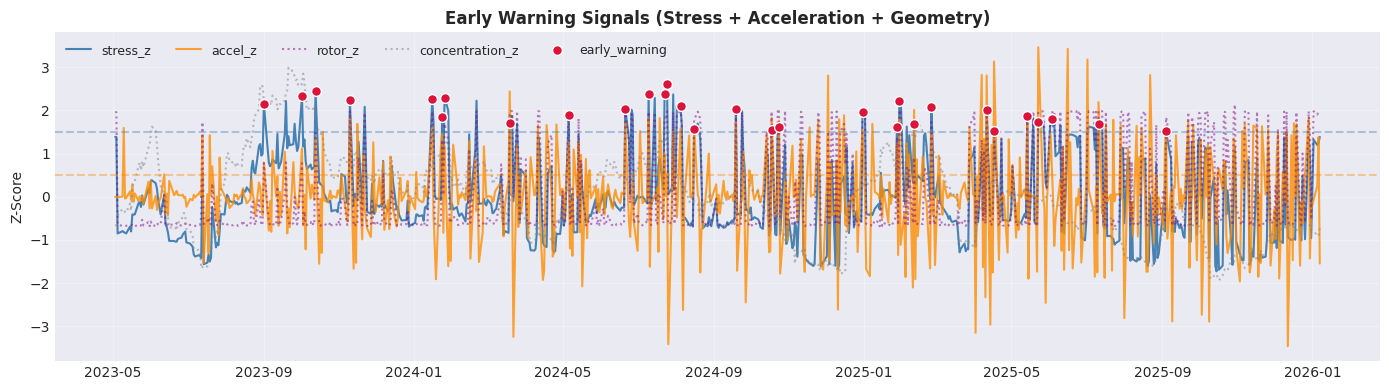

"\n# Cell 11e: Early stress signals (overheat + acceleration + geometry)\nif stress_dim_df.empty or 'stress_index' not in stress_dim_df.columns:\n    print('⚠️ Stress signals not available; skipping early warning.')\nelse:\n    stress_series = stress_dim_df['stress_index'].copy()\n    stress_z = zscore(stress_series)\n    stress_velocity = stress_z.diff().rolling(3).mean()\n    stress_accel = stress_velocity.diff()\n    accel_z = zscore(stress_accel.fillna(0))\n\n    rotor_z = pd.Series(dtype=float)\n    conc_z = pd.Series(dtype=float)\n    if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:\n        geom = geometry_metrics_df.reindex(stress_series.index).ffill().bfill()\n        if 'rotor_shock' in geom:\n            rotor_z = zscore(geom['rotor_shock'])\n        if 'top1_share' in geom:\n            conc_z = zscore(geom['top1_share'])\n        elif 'eff_rank' in geom:\n            conc_z = -zscore(geom['eff_rank'])\n\n    z_threshold = 1.5\n    accel_threshold = 0

In [99]:
# Cell 11e: Early stress signals (overheat + acceleration + geometry)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper to calculate z-score while preserving pandas Index
def pandas_zscore(series):
    if series.dropna().empty or series.std() == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / series.std()

# Check prerequisites
if 'stress_dim_df' not in locals() or stress_dim_df.empty or 'stress_index' not in stress_dim_df.columns:
    print('⚠️ Stress signals not available (stress_dim_df missing or empty).')
    print('   Please ensure Cell 11 ran successfully.')
else:
    # 1. Prepare Stress Z-scores
    stress_series = stress_dim_df['stress_index'].copy()

    # Use pandas for z-score to keep index and allow .diff()
    stress_z = pandas_zscore(stress_series)

    # Velocity and Acceleration
    stress_velocity = stress_z.diff().rolling(3).mean()
    stress_accel = stress_velocity.diff()
    accel_z = pandas_zscore(stress_accel.fillna(0))

    # 2. Prepare Geometry Z-scores
    # Initialize with matching index and NaNs
    rotor_z = pd.Series(np.nan, index=stress_series.index)
    conc_z = pd.Series(np.nan, index=stress_series.index)

    if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
        # Align geometry metrics to stress index
        geom = geometry_metrics_df.reindex(stress_series.index).ffill().bfill()

        if 'rotor_shock' in geom:
            rotor_z = pandas_zscore(geom['rotor_shock'])

        if 'top1_share' in geom:
            conc_z = pandas_zscore(geom['top1_share'])
        elif 'eff_rank' in geom:
            conc_z = -pandas_zscore(geom['eff_rank'])

    # 3. Define Thresholds & Signals
    z_threshold = 1.5
    accel_threshold = 0.5
    rotor_threshold = 1.0
    conc_threshold = 1.0

    # Boolean signals (aligned by index automatically)
    overheat = stress_z > z_threshold
    accelerating = (accel_z > accel_threshold) & (stress_velocity > 0)

    # Handle potentially empty/NaN geometry signals safely
    # We treat NaN as False for alerts
    rotation_alert = (rotor_z > rotor_threshold).fillna(False)
    compression_alert = (conc_z > conc_threshold).fillna(False)

    # Combined Warning
    early_warning = overheat & accelerating & (rotation_alert | compression_alert)

    # Create DataFrame for inspection
    signal_df = pd.DataFrame({
        'stress_index': stress_series,
        'stress_z': stress_z,
        'stress_velocity': stress_velocity,
        'accel_z': accel_z,
        'rotor_z': rotor_z,
        'concentration_z': conc_z,
        'early_warning': early_warning,
    })

    warning_count = early_warning.sum()
    print(f'Early warning count: {int(warning_count)}')

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(stress_series.index, stress_z, label='stress_z', color='steelblue', linewidth=1.5)
    ax.plot(stress_series.index, accel_z, label='accel_z', color='darkorange', linewidth=1.5, alpha=0.8)

    # Plot geometry signals if they have valid data
    if not rotor_z.isna().all():
        ax.plot(stress_series.index, rotor_z, label='rotor_z', color='purple', alpha=0.5, linestyle=':')
    if not conc_z.isna().all():
        ax.plot(stress_series.index, conc_z, label='concentration_z', color='gray', alpha=0.5, linestyle=':')

    # Highlight warnings
    if warning_count > 0:
        warning_dates = stress_series.index[early_warning]
        warning_vals = stress_z[early_warning]
        ax.scatter(
            warning_dates,
            warning_vals,
            color='crimson',
            label='early_warning',
            zorder=5,
            s=50,
            edgecolor='white'
        )

    ax.axhline(z_threshold, color='steelblue', linestyle='--', alpha=0.4)
    ax.axhline(accel_threshold, color='darkorange', linestyle='--', alpha=0.4)

    ax.set_title('Early Warning Signals (Stress + Acceleration + Geometry)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Z-Score')
    ax.legend(ncol=5, fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

'''
# Cell 11e: Early stress signals (overheat + acceleration + geometry)
if stress_dim_df.empty or 'stress_index' not in stress_dim_df.columns:
    print('⚠️ Stress signals not available; skipping early warning.')
else:
    stress_series = stress_dim_df['stress_index'].copy()
    stress_z = zscore(stress_series)
    stress_velocity = stress_z.diff().rolling(3).mean()
    stress_accel = stress_velocity.diff()
    accel_z = zscore(stress_accel.fillna(0))

    rotor_z = pd.Series(dtype=float)
    conc_z = pd.Series(dtype=float)
    if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
        geom = geometry_metrics_df.reindex(stress_series.index).ffill().bfill()
        if 'rotor_shock' in geom:
            rotor_z = zscore(geom['rotor_shock'])
        if 'top1_share' in geom:
            conc_z = zscore(geom['top1_share'])
        elif 'eff_rank' in geom:
            conc_z = -zscore(geom['eff_rank'])

    z_threshold = 1.5
    accel_threshold = 0.5
    rotor_threshold = 1.0
    conc_threshold = 1.0

    overheat = stress_z > z_threshold
    accelerating = (accel_z > accel_threshold) & (stress_velocity > 0)
    rotation_alert = rotor_z > rotor_threshold if not rotor_z.empty else pd.Series(False, index=stress_series.index)
    compression_alert = conc_z > conc_threshold if not conc_z.empty else pd.Series(False, index=stress_series.index)
    early_warning = overheat & accelerating & (rotation_alert | compression_alert)

    signal_df = pd.DataFrame({
        'stress_index': stress_series,
        'stress_z': stress_z,
        'stress_velocity': stress_velocity,
        'accel_z': accel_z,
        'rotor_z': rotor_z,
        'concentration_z': conc_z,
        'early_warning': early_warning,
    })

    print('Early warning count:', int(early_warning.sum()))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(stress_series.index, stress_z, label='stress_z', color='steelblue')
    ax.plot(stress_series.index, accel_z, label='accel_z', color='darkorange')
    if not rotor_z.empty:
        ax.plot(stress_series.index, rotor_z, label='rotor_z', color='purple', alpha=0.5)
    if not conc_z.empty:
        ax.plot(stress_series.index, conc_z, label='concentration_z', color='gray', alpha=0.5)
    ax.scatter(
        stress_series.index[early_warning],
        stress_z[early_warning],
        color='crimson',
        label='early_warning',
        zorder=3,
    )
    ax.axhline(z_threshold, color='steelblue', linestyle='--', alpha=0.4)
    ax.axhline(accel_threshold, color='darkorange', linestyle='--', alpha=0.4)
    ax.set_title('Early Warning Signals')
    ax.legend(ncol=5, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    '''


In [ ]:
# Cell 11b: Geometry regimes per asset (bivector/rotor/ricci)
geometry_models = ['bivector', 'rotor', 'ricci_flow']
regime_results = {model: {} for model in geometry_models}
regime_frames = {model: {} for model in geometry_models}

for symbol, df in price_dfs.items():
    if df.empty:
        continue
    asset_df = df.copy()
    asset_df.index.name = 'date'
    asset_data = df_to_basemodel(asset_df, index=True)

    for model in geometry_models:
        try:
            result = obb.analytics.geometry.regime(
                data=asset_data,
                model=model,
                window=20,
                sensitivity=1.0,
                transition_threshold=0.7,
                source='local',
            )
            regime_results[model][symbol] = result

            model_df = basemodel_to_df(result.results, index='date')
            model_df = normalize_index(model_df)
            if not model_df.empty:
                model_df['symbol'] = symbol
                regime_frames[model][symbol] = model_df

            print(f"✅ {symbol} {model}: {len(result.results)} rows")
        except Exception as e:
            print(f"⚠️ {symbol} {model} failed: {e}")


✅ QQQ bivector: 782 rows


✅ QQQ rotor: 782 rows


✅ QQQ ricci_flow: 782 rows


✅ SPY bivector: 782 rows


✅ SPY rotor: 782 rows


...

✅ DBC rotor: 782 rows


✅ DBC ricci_flow: 782 rows


✅ VIXY bivector: 782 rows


✅ VIXY rotor: 782 rows


✅ VIXY ricci_flow: 782 rows


In [ ]:
# Cell 11c: Geometry factor panels (rotation/contraction)

def build_factor_panel(model_key: str, column: str = 'factor'):
    if not regime_frames.get(model_key):
        return pd.DataFrame()
    df = pd.concat(regime_frames[model_key].values(), axis=0)
    if df.empty:
        return pd.DataFrame()
    df = df.reset_index().rename(columns={'index': 'date'})
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    panel = df.pivot(index='date', columns='symbol', values=column)
    panel = panel.sort_index()
    return panel

bivector_factor = build_factor_panel('bivector', 'factor')
rotor_factor = build_factor_panel('rotor', 'factor')
ricci_factor = build_factor_panel('ricci_flow', 'factor')

rotation_pressure = pd.DataFrame()
contraction_pressure = pd.DataFrame()
shear_pressure = pd.DataFrame()
release_pressure = pd.DataFrame()
combined_signal = pd.DataFrame()

if not rotor_factor.empty:
    rotation_pressure = rotor_factor.diff().rolling(window=5).mean()
    rotation_pressure = rotation_pressure.apply(zscore)

if not ricci_factor.empty:
    contraction_pressure = (-ricci_factor).apply(zscore)
    release_pressure = (-contraction_pressure.diff().rolling(window=3).mean()).apply(zscore)

if not bivector_factor.empty:
    shear_pressure = bivector_factor.apply(zscore)

signals = [sig for sig in [rotation_pressure, contraction_pressure, shear_pressure] if not sig.empty]
if signals:
    combined_signal = sum(signals) / len(signals)

macro_rotation = rotation_pressure.mean(axis=1) if not rotation_pressure.empty else pd.Series(dtype=float)
macro_contraction = contraction_pressure.mean(axis=1) if not contraction_pressure.empty else pd.Series(dtype=float)
macro_release = release_pressure.mean(axis=1) if not release_pressure.empty else pd.Series(dtype=float)
macro_concentration = pd.Series(dtype=float)

if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
    geom = geometry_metrics_df
    if 'rotor_shock' in geom:
        if not macro_rotation.empty:
            macro_rotation = pd.concat([macro_rotation, zscore(geom['rotor_shock'])], axis=1).mean(axis=1)
        else:
            macro_rotation = zscore(geom['rotor_shock'])
    if 'shape_change' in geom:
        if not macro_contraction.empty:
            macro_contraction = pd.concat([macro_contraction, zscore(geom['shape_change'])], axis=1).mean(axis=1)
        else:
            macro_contraction = zscore(geom['shape_change'])
        if not macro_release.empty:
            macro_release = pd.concat([macro_release, -zscore(geom['shape_change'])], axis=1).mean(axis=1)
        else:
            macro_release = -zscore(geom['shape_change'])
    if 'top1_share' in geom:
        macro_concentration = zscore(geom['top1_share'])
    elif 'eff_rank' in geom:
        macro_concentration = -zscore(geom['eff_rank'])

print('Rotation pressure shape:', rotation_pressure.shape)
print('Contraction pressure shape:', contraction_pressure.shape)
print('Release pressure shape:', release_pressure.shape)


Rotation pressure shape: (782, 10)
Contraction pressure shape: (782, 10)
Release pressure shape: (782, 10)


In [ ]:
# Cell 11d: Manifold analysis (spinorial flow) for rotation vs entropy
manifold_input = pd.DataFrame(index=stress_dim_df.index)
if not stress_dim_df.empty:
    manifold_input['stress_index'] = stress_dim_df['stress_index']
if not macro_rotation.empty:
    manifold_input['rotation'] = macro_rotation
if not macro_contraction.empty:
    manifold_input['contraction'] = macro_contraction
if not macro_release.empty:
    manifold_input['release'] = macro_release
if 'macro_concentration' in locals() and not macro_concentration.empty:
    manifold_input['concentration'] = macro_concentration

manifold_input = manifold_input.dropna(how='all')
if manifold_input.empty:
    print('⚠️ manifold_input is empty; skipping manifold analysis.')
else:
    manifold_data = df_to_basemodel(manifold_input, index=True)
    try:
        manifold_result = obb.analytics.geometry.manifold_analysis(
            data=manifold_data,
            method='spinorial_flow',
            fields=list(manifold_input.columns),
            steps=6,
            dt=0.1,
            show_chart=HAS_PLOTLY
        )
        metrics_df = basemodel_to_df(manifold_result.results)
        if metrics_df.empty:
            print('⚠️ Manifold metrics are empty')
        else:
            value_col = None
            for col in ['value', 'val']:
                if col in metrics_df.columns:
                    value_col = col
                    break
            if value_col is None:
                print('⚠️ Manifold metrics missing value column')
                print(metrics_df.head())
            else:
                metrics_wide = metrics_df.pivot(index='symbol', columns='metric', values=value_col)
                print(metrics_wide.head())
    except Exception as e:
        print(f'⚠️ Manifold analysis failed: {e}')


⚠️ manifold_input is empty; skipping manifold analysis.


Rotor field state distribution:
field_state
mixed            532
shear            146
coherent_rise     54
coherent_fall     50
Name: count, dtype: int64


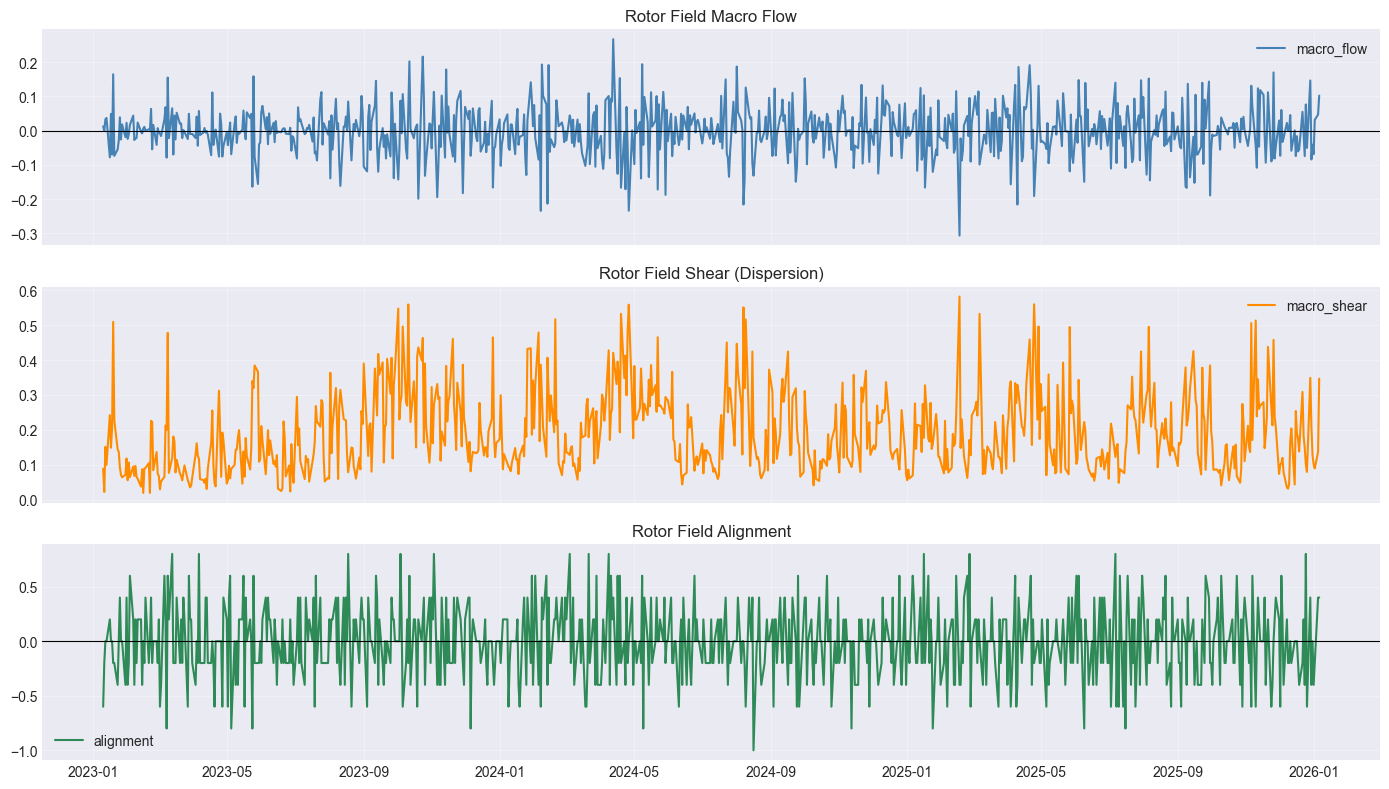

Top rotor leaders (last 20 sessions):
symbol
SPY     0.001858
SGOV    0.001760
LQD     0.000478
IEF     0.000380
VXUS    0.000290
IAU     0.000031
DBC    -0.001395
VIXY   -0.002060
QQQ    -0.007711
TIP    -0.038006
dtype: float64


In [ ]:
# Cell 11f: Rotor field dynamics and regime coupling
if rotor_factor.empty:
    print('⚠️ rotor_factor is empty; skipping rotor field dynamics.')
else:
    rotor_z = rotor_factor.apply(zscore)
    rotor_velocity = rotor_z.diff()
    rotor_accel = rotor_velocity.diff()

    macro_flow = rotor_velocity.mean(axis=1)
    macro_shear = rotor_velocity.std(axis=1)
    alignment = rotor_velocity.apply(np.sign).sum(axis=1) / rotor_velocity.notna().sum(axis=1)

    field_state = pd.Series(index=macro_flow.index, dtype='object')
    field_state[(alignment.abs() >= 0.6) & (macro_flow >= 0)] = 'coherent_rise'
    field_state[(alignment.abs() >= 0.6) & (macro_flow < 0)] = 'coherent_fall'
    field_state[(macro_shear > macro_shear.quantile(0.7)) & (alignment.abs() < 0.3)] = 'shear'
    field_state = field_state.fillna('mixed')

    field_df = pd.DataFrame({
        'macro_flow': macro_flow,
        'macro_shear': macro_shear,
        'alignment': alignment,
        'field_state': field_state,
    })

    if 'geometry_metrics_df' in locals() and not geometry_metrics_df.empty:
        field_df['rotor_shock'] = geometry_metrics_df['rotor_shock'].reindex(field_df.index).ffill().bfill()
        field_df['shape_change'] = geometry_metrics_df['shape_change'].reindex(field_df.index).ffill().bfill()

    print('Rotor field state distribution:')
    print(field_df['field_state'].value_counts())

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(field_df.index, field_df['macro_flow'], label='macro_flow')
    axes[0].plot(field_df.index, field_df['macro_shear'], label='macro_shear')
    axes[0].legend(ncol=2)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(field_df.index, field_df['alignment'], label='alignment', color='slategray')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(field_df.index, field_df['macro_flow'].rolling(5).mean(), label='flow_5d', color='steelblue')
    if 'rotor_shock' in field_df:
        axes[2].plot(field_df.index, zscore(field_df['rotor_shock']), label='rotor_shock_z', color='crimson', alpha=0.5)
    axes[2].legend(ncol=2)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 12: Multi-regime classification (base)
labels = ['Calm', 'Normal', 'Alert', 'Stressed', 'Dislocation']

stress_index = stress_dim_df['stress_index'].replace([np.inf, -np.inf], np.nan)

components = {'stress': zscore(stress_index)} if not stress_index.dropna().empty else {}
if 'macro_rotation' in locals() and not macro_rotation.empty:
    components['rotation'] = zscore(macro_rotation)
if 'macro_contraction' in locals() and not macro_contraction.empty:
    components['contraction'] = zscore(macro_contraction)
if 'macro_concentration' in locals() and not macro_concentration.empty:
    components['concentration'] = zscore(macro_concentration)

weights = {'stress': 0.5, 'rotation': 0.2, 'contraction': 0.2, 'concentration': 0.1}
if components:
    total_w = sum(weights.get(k, 0.0) for k in components)
    if total_w == 0:
        total_w = len(components)
    regime_score = sum(components[k] * weights.get(k, 1.0) for k in components) / total_w
else:
    regime_score = stress_index.copy()

if regime_score.dropna().empty:
    print('⚠️ stress_index is empty; assigning normal regime for all dates.')
    base_regime = pd.Series('Normal', index=stress_dim_df.index, name='regime')
else:
    unique_bins = regime_score.nunique(dropna=True)
    bin_count = max(min(unique_bins, len(labels)), 2)
    active_labels = labels[:bin_count]

    regime_bins = pd.qcut(
        regime_score,
        q=bin_count,
        labels=active_labels,
        duplicates='drop'
    )
    base_regime = regime_bins.rename('regime')

base_regime = base_regime.astype('category')
regime_counts = base_regime.value_counts().sort_index()

print('Regime distribution:')
print(regime_counts)


⚠️ stress_index is empty; assigning normal regime for all dates.
Regime distribution:
regime
Normal    1
Name: count, dtype: int64


In [ ]:
# Cell 12a: Multi-scale consensus regimes (10d/20d/60d)
windows = [10, 20, 60]
regime_by_window = {}

base_series = None
if 'regime_score' in locals():
    base_series = regime_score
else:
    base_series = stress_index

for window in windows:
    series = base_series.rolling(window=window).mean()
    if series.dropna().empty:
        regime_by_window[window] = pd.Series('Normal', index=base_series.index, name=f'regime_{window}')
        continue

    unique_bins = series.nunique(dropna=True)
    bin_count = max(min(unique_bins, len(labels)), 2)
    active_labels = labels[:bin_count]

    regime_bins = pd.qcut(
        series,
        q=bin_count,
        labels=active_labels,
        duplicates='drop'
    )
    regime_by_window[window] = regime_bins.rename(f'regime_{window}').astype('category')

regime_panel = pd.DataFrame(regime_by_window)
regime_panel.columns = [f'regime_{w}' for w in windows]

regime_series = regime_panel.mode(axis=1)[0].astype('category')
agreement_score = regime_panel.eq(regime_series, axis=0).sum(axis=1)

print('Multi-scale consensus regimes:')
print(regime_series.value_counts())
print('Agreement score distribution:')
print(agreement_score.value_counts())


Multi-scale consensus regimes:
0
Normal    1
Name: count, dtype: int64
Agreement score distribution:
3    1
Name: count, dtype: int64


In [ ]:
# Cell 12b: Manifold entropy (rolling regime entropy)
regime_entropy = rolling_entropy(regime_series, window=30)
print('Regime entropy stats:')
print(regime_entropy.describe().round(4))


Regime entropy stats:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64


In [ ]:
# Cell 12c: Multi-asset clustering (geometry distance)
cluster_result = obb.analytics.geometry.multi_asset_clustering(
    data=pga_data,
    target='close',
    num_clusters=3,
    method='spectral',
    distance_metric='geodesic',
    window=20
)

cluster_df = basemodel_to_df(cluster_result.results)
cluster_df = normalize_index(cluster_df)

if cluster_df.empty:
    print('⚠️ cluster_df is empty; skipping cluster summary.')
else:
    if isinstance(cluster_df.index, pd.DatetimeIndex):
        latest_date = cluster_df.index.max()
        latest_clusters = cluster_df.loc[latest_date]
        print(f"Latest cluster snapshot: {latest_date}")
    else:
        latest_clusters = cluster_df.copy()
        print('Latest cluster snapshot: full table (non-datetime index)')

    if isinstance(latest_clusters, pd.Series):
        latest_clusters = latest_clusters.to_frame().T

    cols = [c for c in ['asset', 'cluster_id', 'distance_to_center'] if c in latest_clusters.columns]
    if cols:
        print(latest_clusters[cols].sort_values('cluster_id'))
    else:
        print(latest_clusters.head())

# Geometry-embedding snapshot clusters (fallback/compare)
if not embedding_df.empty and 'symbol' in embedding_df.columns:
    latest_date = embedding_df.index.max()
    latest_embed = embedding_df.loc[latest_date]
    if isinstance(latest_embed, pd.Series):
        latest_embed = latest_embed.to_frame().T

    embed_cols = [c for c in latest_embed.columns if c.startswith('embedding_')]
    if embed_cols:
        if 'embedding_1' in latest_embed.columns:
            latest_embed['cluster_geo'] = pd.qcut(
                latest_embed['embedding_1'],
                q=min(3, latest_embed['embedding_1'].nunique()),
                labels=False,
                duplicates='drop'
            )
            print('Geometry embedding clusters (by embedding_1 quantiles):')
            print(latest_embed[['symbol', 'cluster_geo']].sort_values('cluster_geo'))


Latest cluster snapshot: 1970-01-01 00:00:00
           asset cluster_id distance_to_center
1970-01-01  VIXY          2          40.730624


In [ ]:
# Cell 12d: Manifold distance matrix
distance_result = obb.analytics.geometry.manifold_distance(
    data=pga_data,
    target='close',
    method='geodesic',
    window=20
)

manifold_df = basemodel_to_df(distance_result.results)

pair_candidates = [
    ('asset_1', 'asset_2'),
    ('symbol_1', 'symbol_2'),
    ('asset', 'peer'),
    ('asset', 'asset_2'),
    ('symbol', 'peer'),
]

distance_col = None
for col in ['distance', 'geodesic_distance', 'value']:
    if col in manifold_df.columns:
        distance_col = col
        break

pair_cols = None
for a, b in pair_candidates:
    if a in manifold_df.columns and b in manifold_df.columns:
        pair_cols = (a, b)
        break

if pair_cols and distance_col:
    manifold_df = manifold_df.pivot(index=pair_cols[0], columns=pair_cols[1], values=distance_col)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(manifold_df, cmap='mako', ax=ax)
    ax.set_title('Manifold Distance Matrix (Geodesic)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Manifold distance output columns not recognized.')
    print('Columns:', manifold_df.columns.tolist())
    print(manifold_df.head())

# Geometry embedding distance (latest snapshot)
if not embedding_df.empty and 'symbol' in embedding_df.columns:
    latest_date = embedding_df.index.max()
    latest_embed = embedding_df.loc[latest_date]
    if isinstance(latest_embed, pd.Series):
        latest_embed = latest_embed.to_frame().T

    embed_cols = [c for c in latest_embed.columns if c.startswith('embedding_')]
    if embed_cols:
        embed_vals = latest_embed.set_index('symbol')[embed_cols]
        dist_mat = pd.DataFrame(
            np.linalg.norm(embed_vals.values[:, None, :] - embed_vals.values[None, :, :], axis=2),
            index=embed_vals.index,
            columns=embed_vals.index,
        )
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(dist_mat, cmap='mako', ax=ax)
        ax.set_title('Embedding Distance Matrix (latest date)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()


⚠️ Manifold distance output columns not recognized.
Columns: ['asset1', 'asset2', 'geodesic_distance', 'correlation_angle']
  asset1 asset2  geodesic_distance  correlation_angle
0    QQQ    SPY          81.997074           1.549753
1    QQQ   VXUS          66.087276           1.617551
2    QQQ   SGOV          40.655770           1.740941
3    QQQ    IEF          52.095488           1.687971
4    QQQ    TIP          82.011506           1.447631


In [ ]:
# Cell 12e: Persist geometry outputs to knowledge graph (optional)
from pathlib import Path

graph_base_dir = Path.home() / 'OpenBBUserData' / 'graphs' / 'geometry'
graph_base_dir.mkdir(parents=True, exist_ok=True)

graph_runs = []
try:
    symbols_csv = ','.join(sorted(price_dfs.keys()))

    if symbols_csv and 'pga_result' in locals():
        graph_runs.append(obb.analytics.geometry.graph_build(
            data=pga_result.results,
            graph_type='pga',
            symbol=symbols_csv,
            window=20,
            basis_method='pca',
            graph_base_dir=str(graph_base_dir),
            source='notebook'
        ))

    if 'cluster_result' in locals():
        graph_runs.append(obb.analytics.geometry.graph_build(
            data=cluster_result.results,
            graph_type='clustering',
            symbol=symbols_csv,
            graph_base_dir=str(graph_base_dir),
            source='notebook'
        ))

    if 'distance_result' in locals():
        graph_runs.append(obb.analytics.geometry.graph_build(
            data=distance_result.results,
            graph_type='distance',
            symbol=symbols_csv,
            distance_metric='geodesic',
            graph_base_dir=str(graph_base_dir),
            source='notebook'
        ))

    if 'regime_frames' in locals() and regime_frames.get('rotor'):
        for sym, reg_df in regime_frames['rotor'].items():
            graph_runs.append(obb.analytics.geometry.graph_build(
                data=reg_df,
                graph_type='regime',
                model='rotor',
                symbol=sym,
                graph_base_dir=str(graph_base_dir),
                source='notebook'
            ))

    if graph_runs:
        sample_nodes = obb.analytics.geometry.graph_nodes(limit=5, graph_base_dir=str(graph_base_dir))
        print('Graph nodes sample:')
        print(sample_nodes)
except Exception as e:
    print(f'⚠️ Graph build failed: {e}')


Graph runs saved: 13
Sample graph nodes:
                                               id  node_type          label  \
0  embedding:pga:6022ab5aebab4d14bf3d1eead79d6b72  Embedding  pga_embedding   
1                                       asset:DBC      Asset            DBC   
2                                       asset:IAU      Asset            IAU   
3                                       asset:IEF      Asset            IEF   
4                                       asset:LQD      Asset            LQD   

                                               attrs  \
0  {'window': 20, 'basis_method': 'pca', 'explain...   
1                                  {'symbol': 'DBC'}   
2                                  {'symbol': 'IAU'}   
3                                  {'symbol': 'IEF'}   
4                                  {'symbol': 'LQD'}   

                         created_at       type  
0  2026-01-07T01:28:06.234962+00:00  Embedding  
1  2026-01-07T01:28:06.236601+00:00      Asset  


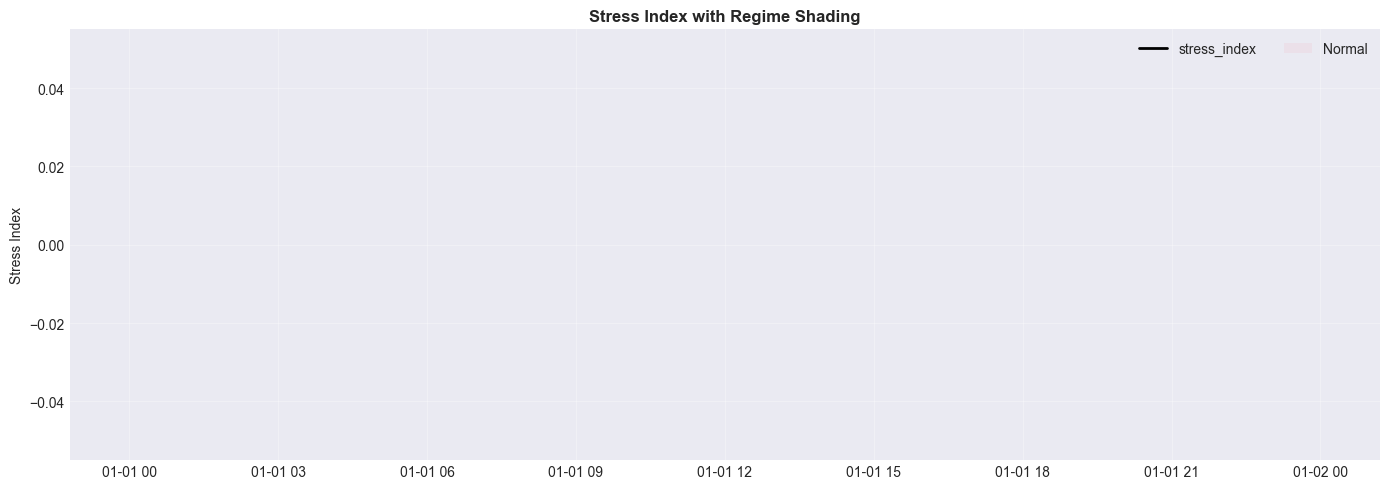

In [ ]:
# Cell 13: Stress index with regime shading
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stress_dim_df.index, stress_dim_df['stress_index'], color='black', linewidth=2, label='stress_index')

for label in regime_series.cat.categories:
    mask = regime_series == label
    ax.fill_between(stress_dim_df.index, 0, stress_dim_df['stress_index'].max(), where=mask, alpha=0.08, label=label)

ax.set_title('Stress Index with Regime Shading', fontsize=12, fontweight='bold')
ax.set_ylabel('Stress Index')
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 14: Early signal analysis (stress + geometry lead)
regime_code = regime_series.cat.codes
regime_change = regime_code.diff().fillna(0)
escalation_dates = regime_series.index[regime_change > 0]
release_dates = regime_series.index[regime_change < 0]

lead_window = 3
asset_scores = {}

for symbol in stress_wide.columns:
    series = stress_wide[symbol]
    z = zscore(series.dropna())
    lead_values = []
    for dt in escalation_dates:
        if dt not in z.index:
            continue
        idx = z.index.get_loc(dt)
        start = max(0, idx - lead_window)
        lead_values.append(z.iloc[start:idx].mean())
    if lead_values:
        asset_scores[symbol] = np.nanmean(lead_values)

signal_df = pd.DataFrame.from_dict(
    asset_scores,
    orient='index',
    columns=['lead_stress_z']
).sort_values('lead_stress_z', ascending=False)

print('Top stress leaders before regime escalation:')
print(signal_df.head(5))

geometry_signal_df = pd.DataFrame()
rotation_signal_df = pd.DataFrame()
release_signal_df = pd.DataFrame()

if not combined_signal.empty:
    geometry_scores = {}
    for symbol in combined_signal.columns:
        series = combined_signal[symbol].dropna()
        if series.empty:
            continue
        lead_values = []
        for dt in escalation_dates:
            if dt not in series.index:
                continue
            idx = series.index.get_loc(dt)
            start = max(0, idx - lead_window)
            lead_values.append(series.iloc[start:idx].mean())
        if lead_values:
            geometry_scores[symbol] = np.nanmean(lead_values)

    geometry_signal_df = pd.DataFrame.from_dict(
        geometry_scores,
        orient='index',
        columns=['lead_geometry_z']
    ).sort_values('lead_geometry_z', ascending=False)

    print('')
    print('Top geometry leaders before regime escalation:')
    print(geometry_signal_df.head(5))

if not rotation_pressure.empty:
    rotation_scores = {}
    for symbol in rotation_pressure.columns:
        series = rotation_pressure[symbol].dropna()
        if series.empty:
            continue
        lead_values = []
        for dt in escalation_dates:
            if dt not in series.index:
                continue
            idx = series.index.get_loc(dt)
            start = max(0, idx - lead_window)
            lead_values.append(series.iloc[start:idx].mean())
        if lead_values:
            rotation_scores[symbol] = np.nanmean(lead_values)

    rotation_signal_df = pd.DataFrame.from_dict(
        rotation_scores,
        orient='index',
        columns=['lead_rotation_z']
    ).sort_values('lead_rotation_z', ascending=False)

    print('')
    print('Top rotation leaders before regime escalation:')
    print(rotation_signal_df.head(5))

if not release_pressure.empty:
    release_scores = {}
    for symbol in release_pressure.columns:
        series = release_pressure[symbol].dropna()
        if series.empty:
            continue
        lead_values = []
        for dt in release_dates:
            if dt not in series.index:
                continue
            idx = series.index.get_loc(dt)
            start = max(0, idx - lead_window)
            lead_values.append(series.iloc[start:idx].mean())
        if lead_values:
            release_scores[symbol] = np.nanmean(lead_values)

    release_signal_df = pd.DataFrame.from_dict(
        release_scores,
        orient='index',
        columns=['lead_release_z']
    ).sort_values('lead_release_z', ascending=False)

    print('')
    print('Top release leaders before regime de-escalation:')
    print(release_signal_df.head(5))


Top stress leaders before regime escalation:
Empty DataFrame
Columns: [lead_stress_z]
Index: []

Top geometry leaders before regime escalation:
Empty DataFrame
Columns: [lead_geometry_z]
Index: []

Top rotation leaders before regime escalation:
Empty DataFrame
Columns: [lead_rotation_z]
Index: []

Top release leaders before regime de-escalation:
Empty DataFrame
Columns: [lead_release_z]
Index: []


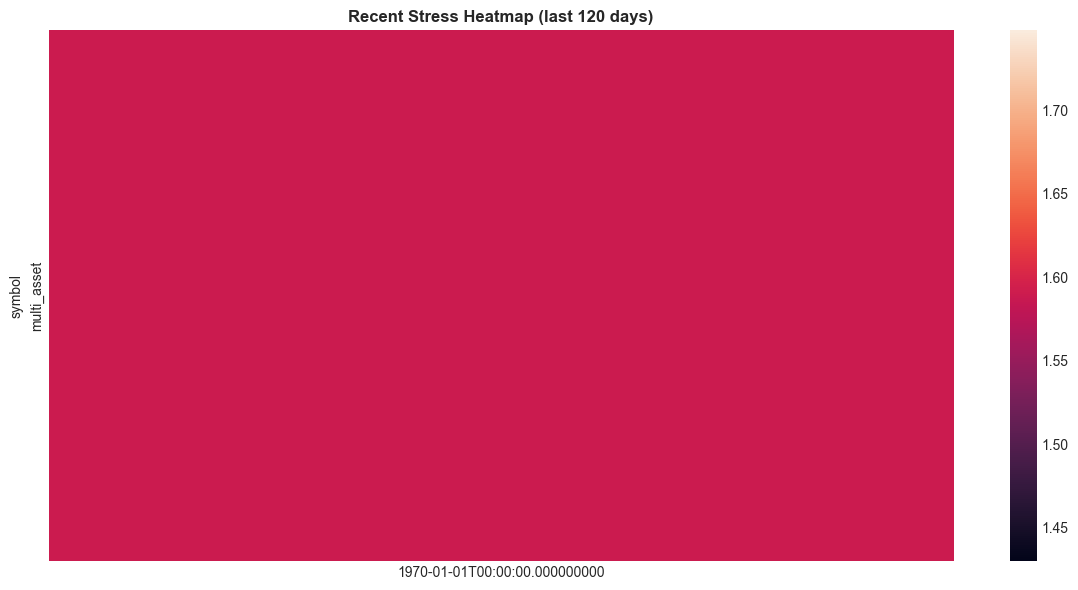

In [ ]:
# Cell 15: Stress heatmap across assets
fig, ax = plt.subplots(figsize=(12, 6))
if not stress_wide.empty:
    sns.heatmap(stress_wide.tail(120).T, cmap='rocket', ax=ax)
    ax.set_title('Recent Stress Heatmap (last 120 days)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ stress_wide is empty')


In [ ]:
# Cell 15a: Calibrate early-warning thresholds (quick sweep)
if 'stress_z' not in locals() or 'accel_z' not in locals() or 'stress_velocity' not in locals():
    print('⚠️ Stress signals not available; skipping calibration.')
else:
    sweep_results = []
    z_grid = [1.0, 1.25, 1.5, 1.75]
    accel_grid = [0.2, 0.5, 0.8]

    if not price_dfs:
        print('⚠️ price_dfs empty; skipping calibration.')
    else:
        risk_on_assets = [s for s in ['QQQ', 'SPY', 'LQD', 'DBC', 'VXUS'] if s in price_dfs]
        risk_off_assets = [s for s in ['SGOV', 'IEF', 'TIP', 'IAU', 'VIXY'] if s in price_dfs]

        returns_panel = {}
        for symbol in set(risk_on_assets + risk_off_assets):
            df = price_dfs[symbol]
            returns_panel[symbol] = df['close'].pct_change()
        returns_df = pd.DataFrame(returns_panel).dropna(how='all')

        if returns_df.empty:
            print('⚠️ returns_df empty; skipping calibration.')
        else:
            macro_stress = stress_dim_df['stress_index'].copy()
            if not macro_contraction.empty:
                macro_stress = macro_stress.add(macro_contraction, fill_value=0)
            macro_stress = macro_stress.reindex(returns_df.index).ffill().bfill()
            stress_threshold = macro_stress.quantile(0.7)

            release = macro_release.reindex(returns_df.index).ffill().fillna(0) if not macro_release.empty else pd.Series(0.0, index=returns_df.index)
            release_threshold = release.quantile(0.6)

            field_state_mask = None
            if 'field_df' in locals() and not field_df.empty:
                field_state_mask = field_df['field_state'].reindex(returns_df.index).ffill().bfill().isin(['coherent_fall', 'shear'])

            for z_threshold in z_grid:
                for accel_threshold in accel_grid:
                    early_warning_local = (stress_z > z_threshold) & (accel_z > accel_threshold) & (stress_velocity > 0)
                    early_warning_local = early_warning_local.reindex(returns_df.index).fillna(False)

                    risk_off_mask = macro_stress > stress_threshold
                    risk_off_mask = risk_off_mask & (release < release_threshold)
                    risk_off_mask = risk_off_mask | early_warning_local
                    if field_state_mask is not None:
                        risk_off_mask = risk_off_mask | field_state_mask

                    risk_on_ret = returns_df[risk_on_assets].mean(axis=1)
                    risk_off_ret = returns_df[risk_off_assets].mean(axis=1) if risk_off_assets else pd.Series(0.0, index=returns_df.index)

                    rotation_ret = pd.Series(
                        np.where(risk_off_mask, risk_off_ret, risk_on_ret),
                        index=returns_df.index
                    ).fillna(0)

                    sharpe = 0.0
                    if rotation_ret.std() > 0:
                        sharpe = (rotation_ret.mean() / rotation_ret.std()) * np.sqrt(252)

                    sweep_results.append({
                        'z_threshold': z_threshold,
                        'accel_threshold': accel_threshold,
                        'sharpe': sharpe,
                        'total_return': (1 + rotation_ret).prod() - 1,
                    })

            sweep_df = pd.DataFrame(sweep_results).sort_values('total_return', ascending=False)
            print('Top early-warning configs by total return:')
            print(sweep_df.head(5))

            if not sweep_df.empty:
                best = sweep_df.iloc[0]
                early_signal_params = {
                    'z_threshold': float(best['z_threshold']),
                    'accel_threshold': float(best['accel_threshold']),
                }
                print(f"Recommended early-signal params: {early_signal_params}")


Top early-warning configs by total return:
   z_threshold  accel_threshold   sharpe  total_return
0         1.00              0.2  1.48191      0.409113
1         1.00              0.5  1.48191      0.409113
2         1.00              0.8  1.48191      0.409113
3         1.25              0.2  1.48191      0.409113
4         1.25              0.5  1.48191      0.409113
Recommended early-signal params: {'z_threshold': 1.0, 'accel_threshold': 0.2}


In [ ]:
# Cell 16: Rotation strategy backtests (optional)
# Use geometry stress + contraction + early-warning overlays to rotate between risk-on and risk-off baskets.
risk_on_assets = [s for s in ['QQQ', 'SPY', 'LQD', 'DBC', 'VXUS'] if s in price_dfs]
risk_off_assets = [s for s in ['SGOV', 'IEF', 'TIP', 'IAU', 'VIXY'] if s in price_dfs]

if not risk_on_assets:
    print('⚠️ No risk-on assets available for rotation backtest.')
else:
    returns_panel = {}
    for symbol in set(risk_on_assets + risk_off_assets):
        df = price_dfs[symbol]
        returns_panel[symbol] = df['close'].pct_change()

    returns_df = pd.DataFrame(returns_panel).dropna(how='all')

    macro_stress = stress_dim_df['stress_index'].copy()
    if not macro_contraction.empty:
        macro_stress = macro_stress.add(macro_contraction, fill_value=0)

    macro_stress = macro_stress.reindex(returns_df.index).ffill().bfill()
    stress_threshold = macro_stress.quantile(0.7)

    risk_off_mask = macro_stress > stress_threshold
    if not macro_release.empty:
        release = macro_release.reindex(returns_df.index).ffill().fillna(0)
        release_threshold = release.quantile(0.6)
        risk_off_mask = risk_off_mask & (release < release_threshold)

    # Overlay PGA early-warning and rotor field shear/fall states
    early_warning_aligned = None
    if 'early_signal_params' in locals():
        z_threshold = early_signal_params.get('z_threshold', 1.5)
        accel_threshold = early_signal_params.get('accel_threshold', 0.5)
        if 'stress_z' in locals() and 'accel_z' in locals() and 'stress_velocity' in locals():
            early_warning_aligned = (stress_z > z_threshold) & (accel_z > accel_threshold) & (stress_velocity > 0)
            early_warning_aligned = early_warning_aligned.reindex(returns_df.index).fillna(False)
    elif 'early_warning' in locals():
        early_warning_aligned = early_warning.reindex(returns_df.index).fillna(False)

    if early_warning_aligned is not None:
        risk_off_mask = risk_off_mask | early_warning_aligned

    field_state_aligned = None
    if 'field_df' in locals() and not field_df.empty:
        field_state_aligned = field_df['field_state'].reindex(returns_df.index).ffill().bfill()
        risk_off_mask = risk_off_mask | field_state_aligned.isin(['coherent_fall', 'shear'])

    risk_on_ret = returns_df[risk_on_assets].mean(axis=1)
    risk_off_ret = returns_df[risk_off_assets].mean(axis=1) if risk_off_assets else pd.Series(0.0, index=returns_df.index)

    rotation_ret = pd.Series(
        np.where(risk_off_mask, risk_off_ret, risk_on_ret),
        index=returns_df.index
    ).fillna(0)

    switch_cost = 0.0005
    switches = risk_off_mask.astype(int).diff().abs().fillna(0)
    rotation_ret = rotation_ret - switches * switch_cost

    rotation_curve = (1 + rotation_ret).cumprod() - 1
    print(f"Rotation strategy cumulative return: {rotation_curve.iloc[-1]:.2%}")

    if 'QQQ' in price_dfs:
        risk_on_df = price_dfs['QQQ'].copy()
        risk_on_df = risk_on_df[['open', 'high', 'low', 'close', 'volume']].dropna()
        risk_off_flag = risk_off_mask.reindex(risk_on_df.index).fillna(False)

        bt_data = risk_on_df.copy()
        bt_data['risk_off'] = risk_off_flag.astype(int)

        try:
            bt_result = obb.backtest.run(
                data=bt_data,
                entry_logic="risk_off == 0",
                exit_logic="risk_off == 1",
                engine="vectorbt"
            )
            print("✅ QQQ risk-on backtest completed")
            if hasattr(bt_result, 'stats'):
                print(bt_result.stats)
        except Exception as e:
            print(f"⚠️ Backtest failed: {e}")

    if risk_off_assets:
        import vectorbt as vbt
        from openbb_backtest.models.results import BacktestResult, BacktestStats, TradeRecord, EquityCurvePoint

        prices = pd.DataFrame({sym: price_dfs[sym]['close'] for sym in set(risk_on_assets + risk_off_assets)})
        prices = prices.reindex(returns_df.index).ffill().bfill()

        # Per-asset no-trade band (base + volatility adjustment)
        base_band = {asset: (0.03 if asset in risk_on_assets else 0.02) for asset in prices.columns}
        vol_adjust = {}
        for asset in prices.columns:
            vol_series = price_dfs[asset].get('volatility_20d')
            if vol_series is not None and vol_series.notna().any():
                vol = float(vol_series.median())
                vol_adjust[asset] = min(0.05, max(0.0, 0.5 * (vol / 100)))
            else:
                vol_adjust[asset] = 0.0
        per_asset_band = pd.Series(base_band) + pd.Series(vol_adjust)

        def build_backtest_result(portfolio, strategy_name, metadata=None):
            vbt_stats = portfolio.stats()
            if isinstance(vbt_stats, pd.DataFrame):
                if 'All' in vbt_stats.columns:
                    stats_series = vbt_stats['All']
                else:
                    stats_series = vbt_stats.mean(axis=1)
            else:
                stats_series = vbt_stats

            def safe_num(value, default=0.0):
                try:
                    if pd.isna(value):
                        return default
                    return float(value)
                except Exception:
                    return default

            max_dd_duration = stats_series.get('Max Drawdown Duration', 0)
            if isinstance(max_dd_duration, pd.Timedelta):
                max_dd_duration_days = int(max_dd_duration / pd.Timedelta(days=1))
            else:
                max_dd_duration_days = safe_num(max_dd_duration, 0)

            avg_trade_dur = stats_series.get('Avg Trade Duration', 0)
            if isinstance(avg_trade_dur, pd.Timedelta):
                avg_trade_dur_days = float(avg_trade_dur / pd.Timedelta(days=1))
            else:
                avg_trade_dur_days = safe_num(avg_trade_dur, 0.0)

            total_trades = stats_series.get('Total Trades', 0)
            if isinstance(total_trades, (pd.Series, pd.DataFrame)):
                total_trades = int(total_trades.sum())
            else:
                total_trades = int(safe_num(total_trades, 0))

            win_rate = safe_num(stats_series.get('Win Rate [%]', 0.0))
            winning_trades = int(win_rate * total_trades / 100) if total_trades > 0 else 0
            losing_trades = total_trades - winning_trades

            equity = portfolio.value()
            if isinstance(equity, pd.DataFrame):
                equity_total = equity.sum(axis=1)
            else:
                equity_total = equity

            stats_dict = {
                'total_return': safe_num(stats_series.get('Total Return [%]', 0.0)),
                'annualized_return': safe_num(stats_series.get('Annualized Return [%]', 0.0)),
                'sharpe_ratio': safe_num(stats_series.get('Sharpe Ratio', 0.0)),
                'sortino_ratio': safe_num(stats_series.get('Sortino Ratio', 0.0)),
                'calmar_ratio': safe_num(stats_series.get('Calmar Ratio', 0.0)),
                'max_drawdown': safe_num(stats_series.get('Max Drawdown [%]', 0.0)),
                'max_drawdown_duration': max_dd_duration_days,
                'avg_drawdown': safe_num(stats_series.get('Avg Drawdown [%]', 0.0)),
                'total_trades': total_trades,
                'winning_trades': winning_trades,
                'losing_trades': losing_trades,
                'win_rate': win_rate,
                'avg_win': safe_num(stats_series.get('Avg Winning Trade [%]', 0.0)),
                'avg_loss': safe_num(stats_series.get('Avg Losing Trade [%]', 0.0)),
                'profit_factor': safe_num(stats_series.get('Profit Factor', 0.0)),
                'expectancy': safe_num(stats_series.get('Expectancy', 0.0)),
                'avg_trade_duration': avg_trade_dur_days,
                'final_equity': safe_num(equity_total.iloc[-1] if len(equity_total) else 0.0),
                'exposure_time': safe_num(stats_series.get('Exposure Time [%]', 0.0)),
            }

            trades_df = portfolio.trades.records_readable if hasattr(portfolio, 'trades') else pd.DataFrame()
            trade_records = []
            if not trades_df.empty:
                def pick_col(names, default=None):
                    for name in names:
                        if name in trades_df.columns:
                            return trades_df[name]
                    return pd.Series([default] * len(trades_df), index=trades_df.index)

                entry_dates = pick_col(['Entry Date', 'Entry Timestamp', 'entry_date'])
                exit_dates = pick_col(['Exit Date', 'Exit Timestamp', 'exit_date'])
                entry_prices = pick_col(['Entry Price', 'entry_price'])
                exit_prices = pick_col(['Exit Price', 'exit_price'])
                sizes = pick_col(['Size', 'size', 'shares'])
                pnls = pick_col(['PnL', 'pnl'])
                pnl_pcts = pick_col(['Return [%]', 'pnl_pct'])
                durations = pick_col(['Duration', 'holding_period'])
                directions = pick_col(['Direction', 'direction'], 'long')

                for idx in trades_df.index:
                    entry_price = float(entry_prices.loc[idx]) if pd.notna(entry_prices.loc[idx]) else None
                    exit_price = float(exit_prices.loc[idx]) if pd.notna(exit_prices.loc[idx]) else None
                    shares = float(sizes.loc[idx]) if pd.notna(sizes.loc[idx]) else None
                    if not entry_price or not exit_price or not shares:
                        continue

                    pnl = float(pnls.loc[idx]) if pd.notna(pnls.loc[idx]) else (exit_price - entry_price) * shares
                    pnl_pct = float(pnl_pcts.loc[idx]) if pd.notna(pnl_pcts.loc[idx]) else (exit_price - entry_price) / entry_price * 100

                    duration_val = durations.loc[idx]
                    if isinstance(duration_val, pd.Timedelta):
                        holding = int(duration_val / pd.Timedelta(days=1))
                    else:
                        holding = int(duration_val) if pd.notna(duration_val) else 0

                    trade_records.append(TradeRecord(
                        entry_date=str(entry_dates.loc[idx]),
                        exit_date=str(exit_dates.loc[idx]),
                        entry_price=entry_price,
                        exit_price=exit_price,
                        shares=shares,
                        pnl=pnl,
                        pnl_pct=pnl_pct,
                        holding_period=holding,
                        direction=str(directions.loc[idx]).lower(),
                    ))

            equity_curve = [
                EquityCurvePoint(date=str(idx), equity=float(val))
                for idx, val in equity_total.items()
            ]

            return BacktestResult(
                strategy_name=strategy_name,
                stats=BacktestStats(**stats_dict),
                trades=trade_records,
                equity_curve=equity_curve,
                metadata=metadata or {},
            )

        weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
        risk_on_weight = 1.0 / len(risk_on_assets)
        risk_off_weight = 1.0 / len(risk_off_assets)

        for sym in risk_on_assets:
            weights.loc[~risk_off_mask, sym] = risk_on_weight
        for sym in risk_off_assets:
            weights.loc[risk_off_mask, sym] = risk_off_weight

        weights = apply_rebalance_threshold(weights, threshold=per_asset_band)

        rotation_portfolio = vbt.Portfolio.from_orders(
            close=prices,
            size=weights,
            size_type='targetpercent',
            init_cash=100000.0,
            fees=0.0005,
            slippage=0.0,
            freq='1D'
        )

        print('✅ Multi-asset rotation portfolio created')
        rotation_backtest_result = build_backtest_result(
            rotation_portfolio,
            'Geometry Rotation (Stress/Contraction)',
            metadata={'risk_on_assets': risk_on_assets, 'risk_off_assets': risk_off_assets}
        )
        print(rotation_backtest_result.stats)

        regime_weight_map = {
            'Calm': {'QQQ': 0.35, 'SPY': 0.25, 'LQD': 0.15, 'DBC': 0.1, 'IAU': 0.15},
            'Normal': {'QQQ': 0.25, 'SPY': 0.25, 'LQD': 0.15, 'IEF': 0.15, 'IAU': 0.1, 'DBC': 0.1},
            'Alert': {'QQQ': 0.15, 'SPY': 0.15, 'LQD': 0.15, 'IEF': 0.2, 'IAU': 0.2, 'SGOV': 0.15},
            'Stressed': {'SGOV': 0.4, 'IEF': 0.2, 'IAU': 0.2, 'VIXY': 0.1, 'TIP': 0.1},
            'Dislocation': {'SGOV': 0.5, 'IAU': 0.25, 'VIXY': 0.15, 'IEF': 0.1},
        }

        regime_weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
        regimes_aligned = regime_series.reindex(prices.index).ffill().bfill()

        for label, weight_map in regime_weight_map.items():
            mask = regimes_aligned == label
            if not mask.any():
                continue
            weights_available = {k: v for k, v in weight_map.items() if k in regime_weights.columns}
            total = sum(weights_available.values())
            if total <= 0:
                continue
            for sym, wgt in weights_available.items():
                regime_weights.loc[mask, sym] = wgt / total

        # Overlay early-warning and rotor field shear/fall states
        overlay_mask = None
        if early_warning_aligned is not None:
            overlay_mask = early_warning_aligned.copy()
        if field_state_aligned is not None:
            overlay_mask = (overlay_mask | field_state_aligned.isin(['coherent_fall', 'shear'])) if overlay_mask is not None else field_state_aligned.isin(['coherent_fall', 'shear'])

        if overlay_mask is not None and overlay_mask.any() and risk_off_assets:
            risk_off_share = early_signal_params.get('risk_off_share', 0.7) if 'early_signal_params' in locals() else 0.7
            risk_on_share = 1.0 - risk_off_share
            for sym in risk_on_assets:
                regime_weights.loc[overlay_mask, sym] = regime_weights.loc[overlay_mask, sym] * risk_on_share
            for sym in risk_off_assets:
                regime_weights.loc[overlay_mask, sym] = risk_off_share / len(risk_off_assets)

        fallback_mask = regime_weights.sum(axis=1) == 0
        if fallback_mask.any():
            fallback_weight = 1.0 / len(risk_on_assets)
            for sym in risk_on_assets:
                regime_weights.loc[fallback_mask, sym] = fallback_weight

        regime_weights = regime_weights.div(regime_weights.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        regime_weights = apply_rebalance_threshold(regime_weights, threshold=per_asset_band)

        regime_portfolio = vbt.Portfolio.from_orders(
            close=prices,
            size=regime_weights,
            size_type='targetpercent',
            init_cash=100000.0,
            fees=0.0005,
            slippage=0.0,
            freq='1D'
        )

        print('✅ Regime-weighted portfolio created')
        regime_backtest_result = build_backtest_result(
            regime_portfolio,
            'Geometry Regime Weights',
            metadata={'regime_weight_map': regime_weight_map}
        )
        print(regime_backtest_result.stats)


Rotation strategy cumulative return: 22.94%


✅ QQQ risk-on backtest completed


✅ Multi-asset rotation portfolio created
total_return=0.7156821095381553 annualized_return=0.0 sharpe_ratio=0.12268410349012929 sortino_ratio=0.18037757601063112 calmar_ratio=0.09608906382806133 max_drawdown=4.594386973677208 max_drawdown_duration=441 avg_drawdown=0.0 total_trades=270 winning_trades=165 losing_trades=105 win_rate=61.23639734790929 avg_win=1.3189588857038745 avg_loss=-1.166927369374695 profit_factor=1.0414534812688974 expectancy=2.0177697871963813 avg_trade_duration=0.0 final_equity=1007156.8210953816 exposure_time=0.0
✅ Regime-weighted portfolio created


total_return=0.02817559574634494 annualized_return=0.0 sharpe_ratio=-0.07556423867929259 sortino_ratio=-0.08417258825919605 calmar_ratio=0.03184602155645383 max_drawdown=4.69928656242422 max_drawdown_duration=520 avg_drawdown=0.0 total_trades=266 winning_trades=155 losing_trades=111 win_rate=58.5453733033105 avg_win=1.3134488719071566 avg_loss=-1.238634021745062 profit_factor=0.9890878046260194 expectancy=-2.5745137936193117 avg_trade_duration=0.0 final_equity=1000281.7559574638 exposure_time=0.0


In [ ]:
# Cell 16a: Rebalance threshold and stress-quantile sweep
if not risk_on_assets:
    print('⚠️ Sweep skipped (no risk-on assets).')
elif 'prices' not in locals():
    print('⚠️ Sweep skipped (portfolio inputs missing).')
else:
    sweep_results = []
    quantiles = [0.6, 0.7, 0.8]
    thresholds = [0.01, 0.03, 0.05]

    for q in quantiles:
        for thr in thresholds:
            stress_threshold = macro_stress.quantile(q)
            mask = macro_stress > stress_threshold

            weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
            risk_on_weight = 1.0 / len(risk_on_assets)
            risk_off_weight = 1.0 / len(risk_off_assets) if risk_off_assets else 0.0

            for sym in risk_on_assets:
                weights.loc[~mask, sym] = risk_on_weight
            for sym in risk_off_assets:
                weights.loc[mask, sym] = risk_off_weight

            weights = apply_rebalance_threshold(weights, threshold=thr)

            import vectorbt as vbt
            portfolio = vbt.Portfolio.from_orders(
                close=prices,
                size=weights,
                size_type='targetpercent',
                init_cash=100000.0,
                fees=0.0005,
                slippage=0.0,
                freq='1D'
            )
            equity = portfolio.value()
            if isinstance(equity, pd.DataFrame):
                end_val = float(equity.sum(axis=1).iloc[-1])
            else:
                end_val = float(equity.iloc[-1])
            sweep_results.append({
                'stress_quantile': q,
                'rebalance_threshold': thr,
                'end_value': end_val,
            })

    sweep_df = pd.DataFrame(sweep_results).sort_values('end_value', ascending=False)
    print('Top sweep results:')
    print(sweep_df.head(5))
    best_params = sweep_df.iloc[0].to_dict()
    print('Best params:', best_params)


Top sweep results:
   stress_quantile  rebalance_threshold     end_value
3              0.7                 0.01  1.026997e+06
4              0.7                 0.03  1.026997e+06
5              0.7                 0.05  1.026997e+06
6              0.8                 0.01  1.023994e+06
7              0.8                 0.03  1.023994e+06
Best params: {'stress_quantile': 0.7, 'rebalance_threshold': 0.01, 'end_value': 1026996.6078462539}


In [ ]:
# Cell 16b: Regime weight-map sweep
if not risk_on_assets or 'prices' not in locals():
    print('⚠️ Regime sweep skipped (inputs missing).')
else:
    sweep_weight_results = []
    risk_on_tilts = [0.9, 1.0, 1.1]
    risk_off_tilts = [0.9, 1.0, 1.1]
    real_assets = {'IAU', 'DBC'}
    real_tilts = [0.9, 1.0, 1.1]

    for on_tilt in risk_on_tilts:
        for off_tilt in risk_off_tilts:
            for real_tilt in real_tilts:
                regime_weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
                regimes_aligned = regime_series.reindex(prices.index).ffill().bfill()

                for label, weight_map in regime_weight_map.items():
                    mask = regimes_aligned == label
                    if not mask.any():
                        continue
                    weights_available = {k: v for k, v in weight_map.items() if k in regime_weights.columns}
                    if not weights_available:
                        continue

                    adjusted = {}
                    for asset, weight in weights_available.items():
                        scale = 1.0
                        if asset in risk_on_assets:
                            scale *= on_tilt
                        if asset in risk_off_assets:
                            scale *= off_tilt
                        if asset in real_assets:
                            scale *= real_tilt
                        adjusted[asset] = weight * scale

                    total = sum(adjusted.values())
                    if total <= 0:
                        continue
                    for asset, weight in adjusted.items():
                        regime_weights.loc[mask, asset] = weight / total

                fallback_mask = regime_weights.sum(axis=1) == 0
                if fallback_mask.any():
                    fallback_weight = 1.0 / len(risk_on_assets)
                    for sym in risk_on_assets:
                        regime_weights.loc[fallback_mask, sym] = fallback_weight

                regime_weights = apply_rebalance_threshold(regime_weights, threshold=per_asset_band)

                import vectorbt as vbt
                portfolio = vbt.Portfolio.from_orders(
                    close=prices,
                    size=regime_weights,
                    size_type='targetpercent',
                    init_cash=100000.0,
                    fees=0.0005,
                    slippage=0.0,
                    freq='1D'
                )

                equity = portfolio.value()
                if isinstance(equity, pd.DataFrame):
                    end_val = float(equity.sum(axis=1).iloc[-1])
                else:
                    end_val = float(equity.iloc[-1])

                sweep_weight_results.append({
                    'risk_on_tilt': on_tilt,
                    'risk_off_tilt': off_tilt,
                    'real_tilt': real_tilt,
                    'end_value': end_val,
                })

    sweep_weight_df = pd.DataFrame(sweep_weight_results).sort_values('end_value', ascending=False)
    print('Top regime weight-map sweeps:')
    print(sweep_weight_df.head(5))


Top regime weight-map sweeps:
    risk_on_tilt  risk_off_tilt  real_tilt     end_value
0            0.9            0.9        0.9  1.034657e+06
14           1.0            1.0        1.1  1.034657e+06
25           1.1            1.1        1.0  1.034657e+06
24           1.1            1.1        0.9  1.034657e+06
23           1.1            1.0        1.1  1.034657e+06


In [ ]:
# Cell 17: Save results to notebook-bridge (optional)
try:
    payload = {
        'stress_index': stress_dim_df[['stress_index']].copy(),
        'stress_leaders': signal_df.copy(),
        'geometry_leaders': geometry_signal_df.copy(),
        'rotation_leaders': rotation_signal_df.copy(),
        'release_leaders': release_signal_df.copy(),
    }

    if not combined_signal.empty:
        payload['combined_signal'] = combined_signal.copy()
    if 'rotation_curve' in locals():
        payload['rotation_curve'] = rotation_curve.to_frame('rotation_return')
    if 'sweep_df' in locals():
        payload['sweep_results'] = sweep_df.copy()

    saved = obb.jupyter.save(
        payload,
        name='multi_asset_geometry_signals',
        tags=['geometry', 'multi_asset', 'regime'],
        notebook_context='multi_asset_regime_analysis.ipynb',
    )
    print(f"✅ Saved signal bundle: {saved.id if hasattr(saved, 'id') else saved}")

    if 'rotation_backtest_result' in locals():
        saved_rotation = obb.jupyter.save(
            rotation_backtest_result,
            name='multi_asset_rotation_backtest',
            tags=['backtest', 'rotation'],
            notebook_context='multi_asset_regime_analysis.ipynb',
        )
        print(f"✅ Saved rotation backtest: {saved_rotation.id if hasattr(saved_rotation, 'id') else saved_rotation}")

    if 'regime_backtest_result' in locals():
        saved_regime = obb.jupyter.save(
            regime_backtest_result,
            name='multi_asset_regime_weights_backtest',
            tags=['backtest', 'regime'],
            notebook_context='multi_asset_regime_analysis.ipynb',
        )
        print(f"✅ Saved regime backtest: {saved_regime.id if hasattr(saved_regime, 'id') else saved_regime}")

except Exception as e:
    try:
        from openbb_notebook_bridge.result_store import ResultStore
        store = ResultStore()
        store.save(
            payload,
            name='multi_asset_geometry_signals',
            tags=['geometry', 'multi_asset', 'regime'],
            notebook_context='multi_asset_regime_analysis.ipynb',
        )
        print('✅ Saved via ResultStore')
    except Exception as inner:
        print(f"⚠️ Notebook-bridge save skipped: {inner}")


✅ Saved signal bundle: 0695dc3a-0575-75bc-8000-25c221fb0fa4
✅ Saved rotation backtest: 0695dc3a-08f2-7580-8000-138d2b56504f


✅ Saved regime backtest: 0695dc3a-097e-72e6-8000-a844588669e2
